In [2]:
import sys 

print(sys.version)
print(sys.executable)

3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
c:\Users\hp\Documents\Global-LandslideGuard-Final2\SIHpp\.venv\Scripts\python.exe


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import geopandas as gpd

import requests
import time

import joblib



In [ ]:
df = pd.read_csv(
    "../data/UGLC_point.csv",
    sep="|"
)

print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_37176\1420388188.py:1: DtypeWarning: Columns (0: VERSION, 1: FATALITIES) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Rows: 1060503
Columns: 18


,WKT_GEOM,NEW DATASET,ID,OLD DATASET,OLD ID,VERSION,COUNTRY,ACCURACY,START DATE,END DATE,TYPE,PHYSICAL FACTORS,RELIABILITY,RECORD TYPE,FATALITIES,INJURIES,NOTES,LINK
0,POINT (-0.0008405636528011627 51.124182780413314),UGLC,1,National Landslide Database (British Geologica...,100002752.0,Last update 2020,United Kingdom,1000,1678/01/01,2023/12/31,ND,ND,8,report,-99999,-99999,"BGS - locality: ""'West Sussex'"", 'Unnamed' - d...",Source: ND
1,POINT (-0.0008488694874882304 51.86155738337304),UGLC,2,National Landslide Database (British Geologica...,100012758.0,Last update 2020,United Kingdom,10,1678/01/01,2023/12/31,ND,ND,2,report,-99999,-99999,"BGS - locality: ""'Ermine Street, Stevenage, He...",Source: ND
2,POINT (-0.0030312674001007275 51.14263826313518),UGLC,3,National Landslide Database (British Geologica...,100020299.0,Last update 2020,United Kingdom,1000,2020/02/13,2020/02/13,ND,ND,7,report,-99999,-99999,"BGS - locality: ""'Dormans Park, Sussex, Englan...",Source: ND
3,POINT (-0.0036346276895752347 52.37416716814228),UGLC,4,National Landslide Database (British Geologica...,100005878.0,Last update 2020,United Kingdom,1000,1678/01/01,2023/12/31,ND,ND,8,report,-99999,-99999,"BGS - locality: ""'Cambridgeshire'"", 'Somersham...",Source: ND
4,POINT (-0.0050965862370939835 51.02532957543868),UGLC,5,National Landslide Database (British Geologica...,100001860.0,Last update 2020,United Kingdom,1000,1678/01/01,2023/12/31,ND,ND,8,report,-99999,-99999,"BGS - locality: ""'East Sussex'"", 'Danehill' - ...",Source: ND


In [ ]:
print(df.shape)

(1060503, 18)


In [ ]:
df.columns.tolist()

['WKT_GEOM',
 'NEW DATASET',
 'ID',
 'OLD DATASET',
 'OLD ID',
 'VERSION',
 'COUNTRY',
 'ACCURACY',
 'START DATE',
 'END DATE',
 'TYPE',
 'PHYSICAL FACTORS',
 'RELIABILITY',
 'RECORD TYPE',
 'FATALITIES',
 'INJURIES',
 'NOTES',
 'LINK']

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1060503 entries, 0 to 1060502
Data columns (total 18 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   WKT_GEOM          1060503 non-null  str   
 1   NEW DATASET       1060503 non-null  str   
 2   ID                1060503 non-null  int64 
 3   OLD DATASET       1060503 non-null  str   
 4   OLD ID            1060042 non-null  str   
 5   VERSION           1060503 non-null  object
 6   COUNTRY           1060446 non-null  str   
 7   ACCURACY          1060503 non-null  int64 
 8   START DATE        1060503 non-null  str   
 9   END DATE          1060503 non-null  str   
 10  TYPE              1060503 non-null  str   
 11  PHYSICAL FACTORS  1060503 non-null  str   
 12  RELIABILITY       1060503 non-null  int64 
 13  RECORD TYPE       1060503 non-null  str   
 14  FATALITIES        1060503 non-null  object
 15  INJURIES          1060503 non-null  int64 
 16  NOTES             1060503 non

/////////////////////////

///////////////////////

In [ ]:
coordinates = df["WKT_GEOM"].str.extract(
    r"POINT \(([-\d.]+) ([-\d.]+)\)"
)

df["longitude"] = pd.to_numeric(coordinates[0])
df["latitude"] = pd.to_numeric(coordinates[1])

print(
    df[
        ["latitude", "longitude"]
    ].head()
)

    latitude  longitude
0  51.124183  -0.000841
1  51.861557  -0.000849
2  51.142638  -0.003031
3  52.374167  -0.003635
4  51.025330  -0.005097


In [ ]:
events = df[
    (df["latitude"] >= -90) &
    (df["latitude"] <= 90) &
    (df["longitude"] >= -180) &
    (df["longitude"] <= 180)
].copy()


print("Valid events:", len(events))

Valid events: 1060494


In [ ]:
np.random.seed(42)

number_of_points = len(events)

background = pd.DataFrame({
    "latitude": np.random.uniform(
        events["latitude"].min(),
        events["latitude"].max(),
        number_of_points
    ),
    "longitude": np.random.uniform(
        events["longitude"].min(),
        events["longitude"].max(),
        number_of_points
    )
})

background["landslide"] = 0

events["landslide"] = 1

print("Landslide points:", len(events))
print("Background points:", len(background))

Landslide points: 1060494
Background points: 1060494


In [ ]:
dataset = pd.concat(
    [
        events[
            [
                "latitude",
                "longitude",
                "landslide"
            ]
        ],
        background
    ],
    ignore_index=True
)

dataset.head()
len(dataset)

2120988

In [ ]:
print(
    dataset["landslide"].value_counts()
)

landslide
1    1060494
0    1060494
Name: count, dtype: int64


///////////////////////

In [ ]:
dataset.to_csv("../data/training_points.csv", index=False)

/////////////////////

In [ ]:
dataset.head()

,latitude,longitude,landslide
0,51.124183,-0.000841,1
1,51.861557,-0.000849,1
2,51.142638,-0.003031,1
3,52.374167,-0.003635,1
4,51.025330,-0.005097,1


In [ ]:
import geopandas as gpd

states = gpd.read_file("../data/india_states.geojson")

print("States loaded:", len(states))
print(states["shapeName"].tolist())

States loaded: 36
['Puducherry', 'Mahārāshtra', 'Nāgāland', 'Lakshadweep', 'Uttar Pradesh', 'Tamil Nādu', 'Chhattīsgarh', 'Gujarāt', 'Delhi', 'Sikkim', 'Tripura', 'West Bengal', 'Odisha', 'Bihār', 'Ladākh', 'Rājasthān', 'Telangāna', 'Andhra Pradesh', 'Mizoram', 'Arunāchal Pradesh', 'Meghālaya', 'Jhārkhand', 'Assam', 'Manipur', 'Karnātaka', 'Uttarākhand', 'Dādra and Nagar Haveli and Damān and Diu', 'Madhya Pradesh', 'Goa', 'Kerala', 'Chandīgarh', 'Andaman and Nicobar Islands', 'Himāchal Pradesh', 'Jammu and Kashmīr', 'Punjab', 'Haryāna']


In [ ]:
import unicodedata

# -----------------------------------
# NORMALIZE STATE NAMES
# Removes accents such as:
# Nāgāland → Nagaland
# Meghālaya → Meghalaya
# Arunāchal Pradesh → Arunachal Pradesh
# -----------------------------------

def normalize_name(name):
    name = str(name)
    name = unicodedata.normalize("NFKD", name)
    name = "".join(
        c for c in name
        if not unicodedata.combining(c)
    )
    return name.strip().casefold()


# -----------------------------------
# ALL 8 NER STATES
# -----------------------------------

ner_state_names = [
    "Arunachal Pradesh",
    "Assam",
    "Manipur",
    "Meghalaya",
    "Mizoram",
    "Nagaland",
    "Sikkim",
    "Tripura"
]

# Normalized versions
ner_names_normalized = {
    normalize_name(name)
    for name in ner_state_names
}


# -----------------------------------
# NORMALIZE GEOJSON STATE NAMES
# -----------------------------------

states["normalized_name"] = states[
    "shapeName"
].apply(normalize_name)


# -----------------------------------
# SELECT NER STATES
# -----------------------------------

ner_states = states[
    states["normalized_name"].isin(
        ner_names_normalized
    )
].copy()


# -----------------------------------
# CHECK RESULT
# -----------------------------------

print("NER states found:")
print(
    ner_states["shapeName"].tolist()
)

print(
    "\nNumber of NER states:",
    len(ner_states)
)

NER states found:
['Nāgāland', 'Sikkim', 'Tripura', 'Mizoram', 'Arunāchal Pradesh', 'Meghālaya', 'Assam', 'Manipur']

Number of NER states: 8


//////////////////////

/////////////////////

In [ ]:
# -----------------------------------
# EXTRACT NER TRAINING POINTS
# -----------------------------------

# Create point geometry from latitude/longitude
points = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(
        df["longitude"],
        df["latitude"]
    ),
    crs="EPSG:4326"
)

# Combine all 8 NER states
ner_boundary = ner_states.geometry.union_all()

# Find points inside NER
inside_ner = points.geometry.within(ner_boundary)

# Keep only NER points
ner_dataset = points.loc[inside_ner].copy()

# Remove geometry column
ner_dataset = ner_dataset.drop(
    columns=["geometry"]
)

# Reset index
ner_dataset.reset_index(
    drop=True,
    inplace=True
)

# -----------------------------------
# CHECK RESULT
# -----------------------------------

print("Total training points:", len(df))
print("NER points:", len(ner_dataset))
print("Outside NER:", len(df) - len(ner_dataset))

print("\nNER dataset columns:")
print(ner_dataset.columns.tolist())

print("\nFirst 5 NER points:")
print(
    ner_dataset[
        ["latitude", "longitude", "landslide"]
    ].head()
)

Total training points: 1060503
NER points: 707
Outside NER: 1059796

NER dataset columns:
['WKT_GEOM', 'NEW DATASET', 'ID', 'OLD DATASET', 'OLD ID', 'VERSION', 'COUNTRY', 'ACCURACY', 'START DATE', 'END DATE', 'TYPE', 'PHYSICAL FACTORS', 'RELIABILITY', 'RECORD TYPE', 'FATALITIES', 'INJURIES', 'NOTES', 'LINK', 'longitude', 'latitude']

First 5 NER points:


KeyError: "['landslide'] not in index"

In [ ]:
ner_dataset

,latitude,longitude,landslide
0,27.256384,88.136123,1
1,27.264400,88.136500,1
2,27.137985,88.155170,1
3,27.347110,88.173924,1
4,27.347110,88.173924,1
...,...,...,...
1283,28.216074,94.885341,0
1284,28.776076,95.834869,0
1285,27.369875,96.789110,0
1286,25.719829,90.090227,0


In [ ]:
# ============================================
# STEP 3 — GET ELEVATION FROM OPEN-METEO
# ============================================

import requests
import pandas as pd
import time
import os

# Make sure we have exactly the NER points
coordinates = ner_dataset[
    ["latitude", "longitude"]
].reset_index(drop=True)

progress_file = "../data/ner_elevation_progress.csv"

# --------------------------------------------
# RESUME IF PARTIAL PROGRESS EXISTS
# --------------------------------------------

if os.path.exists(progress_file):

    progress = pd.read_csv(progress_file)

    elevations = progress["elevation"].tolist()

    start_index = len(elevations)

    print("Previous elevation progress found.")
    print("Already processed:", start_index)

else:

    elevations = []
    start_index = 0

    print("Starting elevation from the beginning.")


# --------------------------------------------
# OPEN-METEO
# --------------------------------------------

url = "https://api.open-meteo.com/v1/elevation"

batch_size = 50

for start in range(start_index, len(coordinates), batch_size):

    batch = coordinates.iloc[
        start:start + batch_size
    ]

    params = {
        "latitude": ",".join(
            batch["latitude"].astype(str)
        ),
        "longitude": ",".join(
            batch["longitude"].astype(str)
        )
    }

    success = False

    for attempt in range(5):

        try:

            response = requests.get(
                url,
                params=params,
                timeout=60
            )

            # --------------------------------
            # SUCCESS
            # --------------------------------

            if response.status_code == 200:

                result = response.json()

                batch_elevations = result["elevation"]

                elevations.extend(
                    batch_elevations
                )

                success = True

                print(
                    "Processed:",
                    min(
                        start + batch_size,
                        len(coordinates)
                    ),
                    "/",
                    len(coordinates)
                )

                # Save progress immediately
                pd.DataFrame({
                    "latitude":
                        coordinates.iloc[
                            :len(elevations)
                        ]["latitude"].values,

                    "longitude":
                        coordinates.iloc[
                            :len(elevations)
                        ]["longitude"].values,

                    "elevation":
                        elevations
                }).to_csv(
                    progress_file,
                    index=False
                )

                # Small delay between requests
                time.sleep(3)

                break

            # --------------------------------
            # RATE LIMITED
            # --------------------------------

            elif response.status_code == 429:

                retry_after = response.headers.get(
                    "Retry-After"
                )

                if retry_after:
                    wait_time = int(retry_after)
                else:
                    wait_time = 30 * (attempt + 1)

                print(
                    "Rate limited."
                )

                print(
                    f"Waiting {wait_time} seconds..."
                )

                time.sleep(wait_time)

            # --------------------------------
            # OTHER ERROR
            # --------------------------------

            else:

                print(
                    "Request failed:",
                    response.status_code
                )

                print(
                    response.text[:300]
                )

                time.sleep(
                    10 * (attempt + 1)
                )

        except requests.RequestException as e:

            print(
                "Connection error:",
                e
            )

            time.sleep(
                10 * (attempt + 1)
            )

    # ----------------------------------------
    # STOP IF BATCH FAILED 5 TIMES
    # ----------------------------------------

    if not success:

        print(
            "\nCould not process batch."
        )

        print(
            "Progress has been saved."
        )

        break


# ============================================
# FINISH
# ============================================

if len(elevations) == len(coordinates):

    ner_dataset["elevation"] = elevations

    print("\n================================")
    print("ELEVATION ADDED SUCCESSFULLY")
    print("================================")

    print(
        "Total elevation values:",
        len(elevations)
    )

    print(
        ner_dataset[
            [
                "latitude",
                "longitude",
                "elevation",
                "landslide"
            ]
        ].head()
    )

else:

    print(
        "\nElevation is only partially processed."
    )

    print(
        "Processed:",
        len(elevations),
        "/",
        len(coordinates)
    )

    print(
        "Run this same cell again to resume."
    )

Starting elevation from the beginning.
Processed: 50 / 1288
Processed: 100 / 1288
Processed: 150 / 1288
Processed: 200 / 1288
Processed: 250 / 1288
Processed: 300 / 1288
Processed: 350 / 1288
Processed: 400 / 1288
Processed: 450 / 1288
Processed: 500 / 1288
Processed: 550 / 1288
Processed: 600 / 1288
Processed: 650 / 1288
Processed: 700 / 1288
Processed: 750 / 1288
Processed: 800 / 1288
Processed: 850 / 1288
Processed: 900 / 1288
Processed: 950 / 1288
Processed: 1000 / 1288
Processed: 1050 / 1288
Processed: 1100 / 1288
Rate limited.
Waiting 30 seconds...
Processed: 1150 / 1288
Processed: 1200 / 1288
Processed: 1250 / 1288
Processed: 1288 / 1288

ELEVATION ADDED SUCCESSFULLY
Total elevation values: 1288
    latitude  longitude  elevation  landslide
0  27.256384  88.136123     1591.0          1
1  27.264400  88.136500     1278.0          1
2  27.137985  88.155170     1234.0          1
3  27.347110  88.173924     2032.0          1
4  27.347110  88.173924     2032.0          1


In [ ]:
ner_dataset

,latitude,longitude,landslide,elevation
0,27.256384,88.136123,1,1591.0
1,27.264400,88.136500,1,1278.0
2,27.137985,88.155170,1,1234.0
3,27.347110,88.173924,1,2032.0
4,27.347110,88.173924,1,2032.0
...,...,...,...,...
1283,28.216074,94.885341,0,444.0
1284,28.776076,95.834869,0,1729.0
1285,27.369875,96.789110,0,1387.0
1286,25.719829,90.090227,0,151.0


In [ ]:
# ============================================
# SAVE NER DATASET WITH ELEVATION + SLOPE
# ============================================

output_file = "../data/ner_dataset.csv"

ner_dataset.to_csv(
    output_file,
    index=False
)

print("NER dataset saved successfully!")
print("File:", output_file)
print("Rows:", len(ner_dataset))
print("Columns:", ner_dataset.columns.tolist())

NER dataset saved successfully!
File: ../data/ner_dataset.csv
Rows: 1288
Columns: ['latitude', 'longitude', 'landslide', 'elevation', 'slope']


In [ ]:
# ============================================
# REALISTIC TERRAIN SLOPE
# Using actual elevation + nearby NER points
# ============================================

import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

# --------------------------------------------
# Check required columns
# --------------------------------------------

required = [
    "latitude",
    "longitude",
    "elevation",
    "landslide"
]

missing = [
    col for col in required
    if col not in ner_dataset.columns
]

if missing:
    raise ValueError(
        f"Missing columns: {missing}"
    )

print("NER points:", len(ner_dataset))


# --------------------------------------------
# Prepare coordinates
# --------------------------------------------

lat = ner_dataset["latitude"].to_numpy(
    dtype=float
)

lon = ner_dataset["longitude"].to_numpy(
    dtype=float
)

elevation = ner_dataset["elevation"].to_numpy(
    dtype=float
)


# --------------------------------------------
# Convert latitude/longitude to metres
# --------------------------------------------

lat0 = np.radians(lat.mean())

meters_per_degree_lat = 111320.0

meters_per_degree_lon = (
    111320.0 * np.cos(lat0)
)

x = (
    lon * meters_per_degree_lon
)

y = (
    lat * meters_per_degree_lat
)


# --------------------------------------------
# Build spatial tree
# --------------------------------------------

points_xy = np.column_stack(
    (x, y)
)

tree = cKDTree(points_xy)


# --------------------------------------------
# Find nearby points
# --------------------------------------------

# 9 = current point + 8 nearest neighbours
distances, neighbours = tree.query(
    points_xy,
    k=9
)


# --------------------------------------------
# Calculate local terrain slope
# --------------------------------------------

slopes = np.zeros(len(ner_dataset))


for i in range(len(ner_dataset)):

    # Nearby points
    idx = neighbours[i]

    # Coordinates relative to current point
    dx = x[idx] - x[i]
    dy = y[idx] - y[i]

    dz = elevation[idx] - elevation[i]

    # Remove the current point
    # because dx=dy=dz=0 for it
    mask = (
        (np.abs(dx) > 0) |
        (np.abs(dy) > 0)
    )

    dx = dx[mask]
    dy = dy[mask]
    dz = dz[mask]

    # ----------------------------------------
    # Fit local terrain plane:
    #
    # elevation = a*x + b*y + c
    # ----------------------------------------

    A = np.column_stack(
        [
            dx,
            dy,
            np.ones(len(dx))
        ]
    )

    coefficients = np.linalg.lstsq(
        A,
        dz,
        rcond=None
    )[0]

    a = coefficients[0]
    b = coefficients[1]

    # ----------------------------------------
    # Terrain gradient
    # ----------------------------------------

    gradient = np.sqrt(
        a**2 + b**2
    )

    # ----------------------------------------
    # Convert gradient to degrees
    # ----------------------------------------

    slopes[i] = np.degrees(
        np.arctan(gradient)
    )


# --------------------------------------------
# Remove impossible values
# --------------------------------------------

slopes = np.nan_to_num(
    slopes,
    nan=0.0,
    posinf=90.0,
    neginf=0.0
)

slopes = np.clip(
    slopes,
    0,
    90
)


# --------------------------------------------
# Add to dataset
# --------------------------------------------

ner_dataset["slope"] = slopes


# ============================================
# RESULTS
# ============================================

print(
    "\n======================================"
)

print(
    "REALISTIC TERRAIN SLOPE CALCULATED"
)

print(
    "======================================"
)

print(
    ner_dataset[
        [
            "latitude",
            "longitude",
            "elevation",
            "slope",
            "landslide"
        ]
    ].head(10)
)


print(
    "\nSlope statistics:"
)

print(
    ner_dataset["slope"].describe()
)

NER points: 1288

REALISTIC TERRAIN SLOPE CALCULATED
    latitude  longitude  elevation     slope  landslide
0  27.256384  88.136123     1591.0  4.482567          1
1  27.264400  88.136500     1278.0  3.535720          1
2  27.137985  88.155170     1234.0  1.298275          1
3  27.347110  88.173924     2032.0  2.069076          1
4  27.347110  88.173924     2032.0  2.069076          1
5  27.347110  88.173924     2032.0  2.069076          1
6  27.348830  88.186784     1791.0  4.060824          1
7  27.138622  88.225518      843.0  3.226014          1
8  27.283295  88.235955     1318.0  6.608796          1
9  27.283295  88.235955     1318.0  6.608796          1

Slope statistics:
count    1288.000000
mean        2.348388
std         3.096384
min         0.000000
25%         0.615743
50%         1.482306
75%         2.808366
max        24.345994
Name: slope, dtype: float64


In [ ]:
import pandas as pd

ner_dataset = pd.read_csv("../data/ner_dataset.csv")

print("NER dataset loaded successfully!")
print("Rows:", len(ner_dataset))
print("Columns:", ner_dataset.columns.tolist())

print("\nFirst 5 rows:")
print(ner_dataset.head())

NER dataset loaded successfully!
Rows: 1288
Columns: ['latitude', 'longitude', 'landslide', 'elevation', 'slope']

First 5 rows:
    latitude  longitude  landslide  elevation     slope
0  27.256384  88.136123          1     1591.0  4.482567
1  27.264400  88.136500          1     1278.0  3.535720
2  27.137985  88.155170          1     1234.0  1.298275
3  27.347110  88.173924          1     2032.0  2.069076
4  27.347110  88.173924          1     2032.0  2.069076


In [ ]:
# ============================================
# SAVE CURRENT NER DATASET BEFORE RAINFALL
# ============================================

output_file = "../data/ner_dataset.csv"

ner_dataset.to_csv(
    output_file,
    index=False
)

print("Current dataset saved successfully!")
print("Rows:", len(ner_dataset))
print("Columns:", ner_dataset.columns.tolist())
print("File:", output_file)


Current dataset saved successfully!
Rows: 1288
Columns: ['latitude', 'longitude', 'landslide', 'elevation', 'slope']
File: ../data/ner_dataset.csv


/////////////////////

////////////////////////

In [ ]:
# ============================================
# ADD REALISTIC ANNUAL RAINFALL
# Open-Meteo Historical Weather
# ============================================



# Load the saved dataset
ner_dataset = pd.read_csv("../data/ner_dataset.csv")

# Create rainfall column if it doesn't exist
if "annual_rainfall" not in ner_dataset.columns:
    ner_dataset["annual_rainfall"] = np.nan

print("NER points:", len(ner_dataset))
print("Rainfall already calculated:",
      ner_dataset["annual_rainfall"].notna().sum())

# Only process points that don't have rainfall yet
remaining = ner_dataset[
    ner_dataset["annual_rainfall"].isna()
].index.tolist()

print("Rainfall remaining:", len(remaining))

# Process 100 locations per API request
batch_size = 100

for start in range(0, len(remaining), batch_size):

    batch_indices = remaining[start:start + batch_size]
    batch = ner_dataset.loc[batch_indices]

    latitudes = ",".join(
        batch["latitude"].astype(str)
    )

    longitudes = ",".join(
        batch["longitude"].astype(str)
    )

    elevations = ",".join(
        batch["elevation"].astype(str)
    )

    params = {
        "latitude": latitudes,
        "longitude": longitudes,
        "elevation": elevations,
        "start_date": "2020-01-01",
        "end_date": "2024-12-31",
        "daily": "precipitation_sum",
        "timezone": "Asia/Kolkata"
    }

    # Retry automatically if Open-Meteo rate-limits us
    while True:

        response = requests.get(
            "https://archive-api.open-meteo.com/v1/archive",
            params=params,
            timeout=120
        )

        if response.status_code == 429:
            print("Rate limited. Waiting 30 seconds...")
            time.sleep(30)
            continue

        response.raise_for_status()
        break

    result = response.json()

    # Multiple coordinates return a list
    if isinstance(result, dict):
        result = [result]

    rainfall_values = []

    for location in result:

        daily_rain = location["daily"]["precipitation_sum"]

        # Convert to numeric
        rain = pd.to_numeric(
            daily_rain,
            errors="coerce"
        )

        # Sum rainfall for each year
        dates = pd.to_datetime(
            location["daily"]["time"]
        )

        yearly_rainfall = (
            pd.Series(rain, index=dates)
            .groupby(dates.year)
            .sum()
        )

        # Average annual rainfall over 2020-2024
        annual_rainfall = yearly_rainfall.mean()

        rainfall_values.append(
            annual_rainfall
        )

    # Store results
    ner_dataset.loc[
        batch_indices,
        "annual_rainfall"
    ] = rainfall_values

    # IMPORTANT: save after every successful batch
    ner_dataset.to_csv(
        "../data/ner_dataset.csv",
        index=False
    )

    processed = start + len(batch_indices)

    print(
        f"Processed rainfall: "
        f"{processed} / {len(remaining)}"
    )

    print(
        "CSV saved successfully."
    )

print("\n================================")
print("RAINFALL ADDED SUCCESSFULLY")
print("================================")

print(
    ner_dataset[
        [
            "latitude",
            "longitude",
            "elevation",
            "slope",
            "annual_rainfall",
            "landslide"
        ]
    ].head(10)
)

print("\nRainfall statistics:")
print(
    ner_dataset["annual_rainfall"].describe()
)

# Final save
ner_dataset.to_csv(
    "../data/ner_dataset.csv",
    index=False
)

print("\nFinal CSV saved successfully!")

NER points: 1288
Rainfall already calculated: 0
Rainfall remaining: 1288
Processed rainfall: 100 / 1288
CSV saved successfully.
Rate limited. Waiting 30 seconds...
Processed rainfall: 200 / 1288
CSV saved successfully.
Rate limited. Waiting 30 seconds...
Processed rainfall: 300 / 1288
CSV saved successfully.
Rate limited. Waiting 30 seconds...
Rate limited. Waiting 30 seconds...
Processed rainfall: 400 / 1288
CSV saved successfully.
Rate limited. Waiting 30 seconds...
Rate limited. Waiting 30 seconds...
Rate limited. Waiting 30 seconds...
Rate limited. Waiting 30 seconds...
Rate limited. Waiting 30 seconds...
Rate limited. Waiting 30 seconds...


KeyboardInterrupt: 

In [ ]:
import pandas as pd

ner_dataset = pd.read_csv("../data/ner_dataset.csv")

print("Rows:", len(ner_dataset))
print("Columns:", ner_dataset.columns.tolist())

if "annual_rainfall" in ner_dataset.columns:
    print(
        "Rainfall values saved:",
        ner_dataset["annual_rainfall"].notna().sum()
    )
else:
    print("Rainfall column does not exist.")

Rows: 1288
Columns: ['latitude', 'longitude', 'landslide', 'elevation', 'slope', 'annual_rainfall']
Rainfall values saved: 400


In [ ]:
print(ner_dataset[["latitude", "longitude", "annual_rainfall"]].head(10))
print()
print("Missing rainfall:", ner_dataset["annual_rainfall"].isna().sum())

    latitude  longitude  annual_rainfall
0  27.256384  88.136123          5811.60
1  27.264400  88.136500          5811.60
2  27.137985  88.155170          7734.80
3  27.347110  88.173924          4140.26
4  27.347110  88.173924          4140.26
5  27.347110  88.173924          4140.26
6  27.348830  88.186784          4140.26
7  27.138622  88.225518          4153.26
8  27.283295  88.235955          5811.60
9  27.283295  88.235955          5811.60

Missing rainfall: 888


In [ ]:
# ============================================================
# FILL RAINFALL FOR DUPLICATE COORDINATES
# ============================================================

import pandas as pd

# Load latest saved CSV
ner_dataset = pd.read_csv("../data/ner_dataset.csv")

print("Before filling:")
print("Total rows:", len(ner_dataset))
print("Rainfall available:", ner_dataset["annual_rainfall"].notna().sum())
print("Rainfall missing:", ner_dataset["annual_rainfall"].isna().sum())

# Create coordinate-based rainfall lookup
rainfall_lookup = (
    ner_dataset
    .dropna(subset=["annual_rainfall"])
    .drop_duplicates(subset=["latitude", "longitude"])
    .set_index(["latitude", "longitude"])["annual_rainfall"]
)

# Fill missing rainfall where the exact same coordinate
# already has a rainfall value
missing_before = ner_dataset["annual_rainfall"].isna().sum()

for idx in ner_dataset.index[ner_dataset["annual_rainfall"].isna()]:
    key = (
        ner_dataset.loc[idx, "latitude"],
        ner_dataset.loc[idx, "longitude"]
    )

    if key in rainfall_lookup.index:
        ner_dataset.loc[idx, "annual_rainfall"] = rainfall_lookup.loc[key]

missing_after = ner_dataset["annual_rainfall"].isna().sum()

print()
print("Duplicate-coordinate rainfall filled:",
      missing_before - missing_after)

print("Rainfall available:", ner_dataset["annual_rainfall"].notna().sum())
print("Rainfall missing:", missing_after)

# SAVE IMMEDIATELY
ner_dataset.to_csv(
    "../data/ner_dataset.csv",
    index=False
)

print()
print("CSV SAVED SUCCESSFULLY!")

Before filling:
Total rows: 1288
Rainfall available: 400
Rainfall missing: 888

Duplicate-coordinate rainfall filled: 0
Rainfall available: 400
Rainfall missing: 888

CSV SAVED SUCCESSFULLY!


In [ ]:
missing = ner_dataset[ner_dataset["annual_rainfall"].isna()].copy()

print("Missing rainfall points:", len(missing))
print("\nFirst 10 missing points:")
print(missing[["latitude", "longitude"]].head(10))

Missing rainfall points: 888

First 10 missing points:
      latitude  longitude
400  26.068381  93.147620
401  25.474900  93.147700
402  24.324205  93.150207
403  25.521500  93.164500
404  25.226900  93.165800
405  25.195355  93.172758
406  24.304157  93.181824
407  24.219888  93.202662
408  24.271730  93.280393
409  28.038049  93.317781


In [ ]:


ner_dataset = pd.read_csv("../data/ner_dataset.csv")

missing = ner_dataset[
    ner_dataset["annual_rainfall"].isna()
]

row = missing.iloc[0]

params = {
    "start": "20240101",
    "end": "20241231",
    "latitude": row["latitude"],
    "longitude": row["longitude"],
    "community": "AG",
    "parameters": "PRECTOTCORR",
    "format": "JSON"
}

print("Testing NASA POWER")
print("Latitude:", row["latitude"])
print("Longitude:", row["longitude"])

response = requests.get(
    "https://power.larc.nasa.gov/api/temporal/daily/point",
    params=params,
    timeout=60
)

print()
print("HTTP status:", response.status_code)

if response.status_code == 200:
    data = response.json()

    rainfall = data["properties"]["parameter"]["PRECTOTCORR"]

    annual_rainfall = sum(
        value for value in rainfall.values()
        if value is not None
    )

    print("SUCCESS!")
    print("2024 annual rainfall:", annual_rainfall, "mm")

else:
    print("NASA POWER ERROR:")
    print(response.text[:1000])

Testing NASA POWER
Latitude: 26.06838073
Longitude: 93.14761961

HTTP status: 200
SUCCESS!
2024 annual rainfall: 1366.74 mm


In [ ]:
# ============================================
# FILL MISSING ANNUAL RAINFALL
# NASA POWER
# RESUMABLE + CSV CHECKPOINT
# ============================================

import pandas as pd
import numpy as np
import requests
import time

# Load latest saved dataset
ner_dataset = pd.read_csv("../data/ner_dataset.csv")

# Create column if missing
if "annual_rainfall" not in ner_dataset.columns:
    ner_dataset["annual_rainfall"] = np.nan

print("Total NER points:", len(ner_dataset))

already_saved = ner_dataset["annual_rainfall"].notna().sum()

print("Rainfall already saved:", already_saved)

# ONLY missing rows
remaining = ner_dataset[
    ner_dataset["annual_rainfall"].isna()
].index.tolist()

print("Rainfall remaining:", len(remaining))


# ============================================
# SETTINGS
# ============================================

batch_size = 20

success_count = 0


# ============================================
# PROCESS MISSING POINTS
# ============================================

for start in range(0, len(remaining), batch_size):

    batch_indices = remaining[start:start + batch_size]

    print()
    print(
        f"Processing {start + 1} - "
        f"{start + len(batch_indices)} "
        f"/ {len(remaining)}"
    )

    for index in batch_indices:

        latitude = ner_dataset.loc[index, "latitude"]
        longitude = ner_dataset.loc[index, "longitude"]

        params = {
            "start": "20240101",
            "end": "20241231",
            "latitude": latitude,
            "longitude": longitude,
            "community": "AG",
            "parameters": "PRECTOTCORR",
            "format": "JSON"
        }

        try:

            response = requests.get(
                "https://power.larc.nasa.gov/api/temporal/daily/point",
                params=params,
                timeout=60
            )

            if response.status_code != 200:

                print(
                    f"API error at index {index}: "
                    f"{response.status_code}"
                )

                continue

            data = response.json()

            rainfall = (
                data["properties"]
                ["parameter"]
                ["PRECTOTCORR"]
            )

            annual_rainfall = sum(
                float(value)
                for value in rainfall.values()
                if value is not None
            )

            # Save value immediately in dataframe
            ner_dataset.loc[
                index,
                "annual_rainfall"
            ] = annual_rainfall

            success_count += 1

            print(
                f"Saved {success_count}: "
                f"index={index}, "
                f"rainfall={annual_rainfall:.2f} mm"
            )

        except Exception as e:

            print(
                f"Error at index {index}: {e}"
            )

        # Small delay between requests
        time.sleep(0.5)


    # ========================================
    # SAVE AFTER EVERY BATCH
    # ========================================

    ner_dataset.to_csv(
        "../data/ner_dataset.csv",
        index=False
    )

    saved_now = ner_dataset[
        "annual_rainfall"
    ].notna().sum()

    missing_now = ner_dataset[
        "annual_rainfall"
    ].isna().sum()

    print()
    print("CSV CHECKPOINT SAVED")
    print("Rainfall saved:", saved_now)
    print("Rainfall remaining:", missing_now)


# ============================================
# FINAL CHECK
# ============================================

ner_dataset.to_csv(
    "../data/ner_dataset.csv",
    index=False
)

print()
print("================================")
print("RAINFALL PROCESSING FINISHED")
print("================================")

print("Total points:", len(ner_dataset))

print(
    "Rainfall available:",
    ner_dataset["annual_rainfall"].notna().sum()
)

print(
    "Rainfall missing:",
    ner_dataset["annual_rainfall"].isna().sum()
)

print()
print(
    ner_dataset[
        [
            "latitude",
            "longitude",
            "elevation",
            "slope",
            "annual_rainfall",
            "landslide"
        ]
    ].head(10)
)

print()
print("Rainfall statistics:")
print(
    ner_dataset["annual_rainfall"].describe()
)

Total NER points: 1288
Rainfall already saved: 400
Rainfall remaining: 888

Processing 1 - 20 / 888
Saved 1: index=400, rainfall=1366.74 mm
Saved 2: index=401, rainfall=1795.44 mm
Saved 3: index=402, rainfall=2512.51 mm
Saved 4: index=403, rainfall=1795.44 mm
Saved 5: index=404, rainfall=2378.52 mm
Saved 6: index=405, rainfall=2378.52 mm
Saved 7: index=406, rainfall=2512.51 mm
Saved 8: index=407, rainfall=2367.18 mm
Saved 9: index=408, rainfall=2512.51 mm
Saved 10: index=409, rainfall=1571.42 mm
Saved 11: index=410, rainfall=1571.42 mm
Saved 12: index=411, rainfall=1571.42 mm
Saved 13: index=412, rainfall=1571.42 mm
Saved 14: index=413, rainfall=1795.44 mm
Saved 15: index=414, rainfall=2309.20 mm
Saved 16: index=415, rainfall=2309.20 mm
Saved 17: index=416, rainfall=2378.52 mm
Saved 18: index=417, rainfall=2309.20 mm
Saved 19: index=418, rainfall=1571.42 mm
Saved 20: index=419, rainfall=1571.42 mm

CSV CHECKPOINT SAVED
Rainfall saved: 420
Rainfall remaining: 868

Processing 21 - 40 / 8

In [ ]:
import pandas as pd

ner_dataset = pd.read_csv("../data/ner_dataset.csv")

print("Rows:", len(ner_dataset))
print("Columns:", ner_dataset.columns.tolist())

print("\nMissing values:")
print(ner_dataset.isna().sum())

print("\nLandslide distribution:")
print(ner_dataset["landslide"].value_counts())

print("\nFirst 5 rows:")
print(ner_dataset.head())

Rows: 1288
Columns: ['latitude', 'longitude', 'landslide', 'elevation', 'slope', 'annual_rainfall']

Missing values:
latitude           0
longitude          0
landslide          0
elevation          0
slope              0
annual_rainfall    0
dtype: int64

Landslide distribution:
landslide
1    707
0    581
Name: count, dtype: int64

First 5 rows:
    latitude  longitude  landslide  elevation     slope  annual_rainfall
0  27.256384  88.136123          1     1591.0  4.482567          5811.60
1  27.264400  88.136500          1     1278.0  3.535720          5811.60
2  27.137985  88.155170          1     1234.0  1.298275          7734.80
3  27.347110  88.173924          1     2032.0  2.069076          4140.26
4  27.347110  88.173924          1     2032.0  2.069076          4140.26


In [ ]:
# ============================================
# PREPARE DATA FOR MACHINE LEARNING
# ============================================

import pandas as pd

# Load final saved dataset
ner_dataset = pd.read_csv("../data/ner_dataset.csv")

# Features
X = ner_dataset[
    [
        "latitude",
        "longitude",
        "elevation",
        "slope",
        "annual_rainfall"
    ]
]

# Target
y = ner_dataset["landslide"]

print("Dataset shape:", ner_dataset.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nDataset ready for ML.")

Dataset shape: (1288, 6)

Features:
['latitude', 'longitude', 'elevation', 'slope', 'annual_rainfall']

Feature shape: (1288, 5)
Target shape: (1288,)

Target distribution:
landslide
1    707
0    581
Name: count, dtype: int64

Dataset ready for ML.


In [ ]:
import requests

url = "https://files.isric.org/soilgrids/latest/data/"

response = requests.get(
    url,
    timeout=30
)

print("HTTP status:", response.status_code)

if response.status_code == 200:
    print("SoilGrids data server is accessible.")
else:
    print(response.text[:500])

HTTP status: 200
SoilGrids data server is accessible.


In [ ]:
import geopandas as gpd
import rasterio
import pandas as pd

print("GeoPandas:", gpd.__version__)
print("Rasterio:", rasterio.__version__)
print("Pandas:", pd.__version__)
print("All required libraries are available.")

GeoPandas: 1.1.4
Rasterio: 1.5.1
Pandas: 3.0.5
All required libraries are available.


In [ ]:
import pandas as pd

ner_dataset = pd.read_csv("../data/ner_dataset.csv")

min_lat = ner_dataset["latitude"].min()
max_lat = ner_dataset["latitude"].max()
min_lon = ner_dataset["longitude"].min()
max_lon = ner_dataset["longitude"].max()

print("NER bounding box:")
print("Minimum latitude :", min_lat)
print("Maximum latitude :", max_lat)
print("Minimum longitude:", min_lon)
print("Maximum longitude:", max_lon)

print("\nTotal NER points:", len(ner_dataset))

NER bounding box:
Minimum latitude : 22.148327
Maximum latitude : 29.346549082067305
Minimum longitude: 88.13612339
Maximum longitude: 97.32706971129866

Total NER points: 1288


In [ ]:
# ============================================
# DOWNLOAD SOILGRIDS DATA FOR NER AREA
# WCS - 0 to 5 cm - Median prediction
# ============================================

import os
import requests
import pandas as pd

ner_dataset = pd.read_csv("../data/ner_dataset.csv")

min_lat = ner_dataset["latitude"].min()
max_lat = ner_dataset["latitude"].max()
min_lon = ner_dataset["longitude"].min()
max_lon = ner_dataset["longitude"].max()

soil_dir = "../data/soilgrids"
os.makedirs(soil_dir, exist_ok=True)

base_url = "https://maps.isric.org/mapserv"

properties = {
    "clay": "clay_0-5cm_Q0.5",
    "sand": "sand_0-5cm_Q0.5",
    "ph": "phh2o_0-5cm_Q0.5"
}

for name, coverage in properties.items():

    output_file = os.path.join(
        soil_dir,
        f"{name}_0-5cm.tif"
    )

    if os.path.exists(output_file):
        print(f"{name}: already downloaded")
        continue

    params = {
        "map": f"/map/{name if name != 'ph' else 'phh2o'}.map",
        "SERVICE": "WCS",
        "VERSION": "2.0.1",
        "REQUEST": "GetCoverage",
        "COVERAGEID": coverage,
        "FORMAT": "GEOTIFF_INT16",

        "SUBSET": [
            f"X({min_lon},{max_lon})",
            f"Y({min_lat},{max_lat})"
        ],

        "SUBSETTINGCRS":
            "http://www.opengis.net/def/crs/EPSG/0/4326",

        "OUTPUTCRS":
            "http://www.opengis.net/def/crs/EPSG/0/4326"
    }

    print()
    print("Downloading:", name)
    print("Coverage:", coverage)

    response = requests.get(
        base_url,
        params=params,
        timeout=300
    )

    print("HTTP status:", response.status_code)

    response.raise_for_status()

    with open(output_file, "wb") as f:
        f.write(response.content)

    size_mb = os.path.getsize(output_file) / (1024 * 1024)

    print(
        f"{name} saved successfully "
        f"({size_mb:.1f} MB)"
    )

print()
print("================================")
print("SOILGRIDS DOWNLOAD COMPLETE")
print("================================")

print("Files:")
for file in os.listdir(soil_dir):
    print("-", file)


Downloading: clay
Coverage: clay_0-5cm_Q0.5
HTTP status: 200
clay saved successfully (10.0 MB)

Downloading: sand
Coverage: sand_0-5cm_Q0.5


ConnectionError: HTTPSConnectionPool(host='maps.isric.org', port=443): Read timed out.

In [ ]:
import os
import requests

soil_dir = "../data/soilgrids"
os.makedirs(soil_dir, exist_ok=True)

output_file = os.path.join(
    soil_dir,
    "sand_0-5cm.tif"
)

url = "https://maps.isric.org/mapserv"

params = {
    "map": "/map/sand.map",
    "SERVICE": "WCS",
    "VERSION": "2.0.1",
    "REQUEST": "GetCoverage",
    "COVERAGEID": "sand_0-5cm_Q0.5",
    "FORMAT": "GEOTIFF_INT16",

    "SUBSET": [
        "X(88.13612339,97.32706971129866)",
        "Y(22.148327,29.346549082067305)"
    ],

    "SUBSETTINGCRS":
        "http://www.opengis.net/def/crs/EPSG/0/4326",

    "OUTPUTCRS":
        "http://www.opengis.net/def/crs/EPSG/0/4326"
}

print("Downloading SAND...")
print("Please wait...")

response = requests.get(
    url,
    params=params,
    timeout=600
)

print("HTTP status:", response.status_code)

response.raise_for_status()

with open(output_file, "wb") as f:
    f.write(response.content)

print("SAND SAVED SUCCESSFULLY!")
print(
    "Size:",
    round(os.path.getsize(output_file) / (1024 * 1024), 2),
    "MB"
)

Please wait...
HTTP status: 200
SAND SAVED SUCCESSFULLY!
Size: 10.45 MB


In [ ]:
import os
import requests

soil_dir = "../data/soilgrids"
output_file = os.path.join(soil_dir, "ph_0-5cm.tif")

url = "https://maps.isric.org/mapserv"

params = {
    "map": "/map/phh2o.map",
    "SERVICE": "WCS",
    "VERSION": "2.0.1",
    "REQUEST": "GetCoverage",
    "COVERAGEID": "phh2o_0-5cm_Q0.5",
    "FORMAT": "GEOTIFF_INT16",

    "SUBSET": [
        "X(88.13612339,97.32706971129866)",
        "Y(22.148327,29.346549082067305)"
    ],

    "SUBSETTINGCRS":
        "http://www.opengis.net/def/crs/EPSG/0/4326",

    "OUTPUTCRS":
        "http://www.opengis.net/def/crs/EPSG/0/4326"
}

print("Downloading SOIL pH...")
print("Please wait...")

response = requests.get(
    url,
    params=params,
    timeout=600
)

print("HTTP status:", response.status_code)

response.raise_for_status()

with open(output_file, "wb") as f:
    f.write(response.content)

print("PH SAVED SUCCESSFULLY!")
print(
    "Size:",
    round(os.path.getsize(output_file) / (1024 * 1024), 2),
    "MB"
)

Please wait...
HTTP status: 200
PH SAVED SUCCESSFULLY!
Size: 4.24 MB


In [ ]:
# ============================================
# EXTRACT SOIL FEATURES FOR NER POINTS
# ============================================

import pandas as pd
import geopandas as gpd
import rasterio

# Load current dataset
ner_dataset = pd.read_csv("../data/ner_dataset.csv")

# Raster files
rasters = {
    "soil_clay": "../data/soilgrids/clay_0-5cm.tif",
    "soil_sand": "../data/soilgrids/sand_0-5cm.tif",
    "soil_ph": "../data/soilgrids/ph_0-5cm.tif"
}

# Coordinates
coordinates = list(
    zip(
        ner_dataset["longitude"],
        ner_dataset["latitude"]
    )
)

# Extract each raster value
for feature, raster_file in rasters.items():

    print(f"Extracting {feature}...")

    with rasterio.open(raster_file) as src:

        values = []

        for value in src.sample(coordinates):

            value = value[0]

            if src.nodata is not None and value == src.nodata:
                values.append(float("nan"))
            else:
                values.append(float(value))

    ner_dataset[feature] = values

    # SoilGrids stores pH/clay/sand with scaling factors
    if feature == "soil_ph":
        ner_dataset[feature] = ner_dataset[feature] / 10

    elif feature in ["soil_clay", "soil_sand"]:
        ner_dataset[feature] = ner_dataset[feature] / 10

    # SAVE AFTER EACH FEATURE
    ner_dataset.to_csv(
        "../data/ner_dataset.csv",
        index=False
    )

    print(f"{feature} extracted and CSV saved.")
    print("Missing:", ner_dataset[feature].isna().sum())

print()
print("================================")
print("SOIL FEATURES ADDED SUCCESSFULLY")
print("================================")

print("Rows:", len(ner_dataset))

print(
    ner_dataset[
        [
            "latitude",
            "longitude",
            "soil_clay",
            "soil_sand",
            "soil_ph",
            "landslide"
        ]
    ].head(10)
)

print("\nMissing values:")
print(
    ner_dataset[
        ["soil_clay", "soil_sand", "soil_ph"]
    ].isna().sum()
)

# FINAL SAVE
ner_dataset.to_csv(
    "../data/ner_dataset.csv",
    index=False
)

print("\nFINAL CSV SAVED!")

Extracting soil_clay...
soil_clay extracted and CSV saved.
Missing: 0
Extracting soil_sand...
soil_sand extracted and CSV saved.
Missing: 0
Extracting soil_ph...
soil_ph extracted and CSV saved.
Missing: 0

SOIL FEATURES ADDED SUCCESSFULLY
Rows: 1288
    latitude  longitude  soil_clay  soil_sand  soil_ph  landslide
0  27.256384  88.136123       18.6       30.9      5.3          1
1  27.264400  88.136500       16.7       32.5      5.3          1
2  27.137985  88.155170       22.3       33.7      5.4          1
3  27.347110  88.173924       13.2       45.0      5.2          1
4  27.347110  88.173924       13.2       45.0      5.2          1
5  27.347110  88.173924       13.2       45.0      5.2          1
6  27.348830  88.186784       13.0       46.8      5.2          1
7  27.138622  88.225518       18.8       34.8      5.2          1
8  27.283295  88.235955       17.1       34.1      5.4          1
9  27.283295  88.235955       17.1       34.1      5.4          1

Missing values:
soil_c

In [ ]:
ner_dataset.head()

,latitude,longitude,landslide,elevation,slope,annual_rainfall,soil_clay,soil_sand,soil_ph
0,27.256384,88.136123,1,1591.0,4.482567,5811.60,18.6,30.9,5.3
1,27.264400,88.136500,1,1278.0,3.535720,5811.60,16.7,32.5,5.3
2,27.137985,88.155170,1,1234.0,1.298275,7734.80,22.3,33.7,5.4
3,27.347110,88.173924,1,2032.0,2.069076,4140.26,13.2,45.0,5.2
4,27.347110,88.173924,1,2032.0,2.069076,4140.26,13.2,45.0,5.2


In [ ]:
# ============================================
# FINAL DATASET VERIFICATION
# ============================================

import pandas as pd

ner_dataset = pd.read_csv("../data/ner_dataset.csv")

print("============================================")
print("FINAL DATASET VERIFICATION")
print("============================================")

# 1. Dataset size
print("\n1. DATASET SIZE")
print("Rows:", len(ner_dataset))
print("Columns:", len(ner_dataset.columns))

# 2. Columns
print("\n2. COLUMNS")
print(ner_dataset.columns.tolist())

# 3. Missing values
print("\n3. MISSING VALUES")
print(ner_dataset.isna().sum())

# 4. Duplicate coordinates
print("\n4. DUPLICATE COORDINATES")
duplicates = ner_dataset.duplicated(
    subset=["latitude", "longitude"]
).sum()
print("Duplicate coordinates:", duplicates)

# 5. Landslide distribution
print("\n5. LANDSLIDE DISTRIBUTION")
print(ner_dataset["landslide"].value_counts())

# 6. Feature statistics
features = [
    "elevation",
    "slope",
    "annual_rainfall",
    "soil_clay",
    "soil_sand",
    "soil_ph"
]

print("\n6. FEATURE STATISTICS")
print(ner_dataset[features].describe())

# 7. Check invalid values
print("\n7. VALUE CHECKS")

print(
    "Invalid latitude:",
    ((ner_dataset["latitude"] < -90) |
     (ner_dataset["latitude"] > 90)).sum()
)

print(
    "Invalid longitude:",
    ((ner_dataset["longitude"] < -180) |
     (ner_dataset["longitude"] > 180)).sum()
)

print(
    "Negative elevation:",
    (ner_dataset["elevation"] < 0).sum()
)

print(
    "Negative rainfall:",
    (ner_dataset["annual_rainfall"] < 0).sum()
)

print(
    "Invalid soil pH:",
    ((ner_dataset["soil_ph"] < 0) |
     (ner_dataset["soil_ph"] > 14)).sum()
)

print("\n============================================")
print("DATASET READY FOR ML")
print("============================================")

FINAL DATASET VERIFICATION

1. DATASET SIZE
Rows: 1288
Columns: 9

2. COLUMNS
['latitude', 'longitude', 'landslide', 'elevation', 'slope', 'annual_rainfall', 'soil_clay', 'soil_sand', 'soil_ph']

3. MISSING VALUES
latitude           0
longitude          0
landslide          0
elevation          0
slope              0
annual_rainfall    0
soil_clay          0
soil_sand          0
soil_ph            0
dtype: int64

4. DUPLICATE COORDINATES
Duplicate coordinates: 72

5. LANDSLIDE DISTRIBUTION
landslide
1    707
0    581
Name: count, dtype: int64

6. FEATURE STATISTICS
         elevation        slope  annual_rainfall    soil_clay    soil_sand  \
count  1288.000000  1288.000000      1288.000000  1288.000000  1288.000000   
mean    985.680124     2.348388      2371.691475    19.480435    31.773059   
std    1022.816338     3.096384       935.164332     7.634797    13.065052   
min       9.000000     0.000000       780.770000     0.000000     0.000000   
25%     148.750000     0.615743      1

In [ ]:
# Check suspicious soil pH values

print("Soil pH = 0:", (ner_dataset["soil_ph"] == 0).sum())

print("\nRows with soil pH = 0:")
print(
    ner_dataset[
        ner_dataset["soil_ph"] == 0
    ][
        [
            "latitude",
            "longitude",
            "soil_ph",
            "landslide"
        ]
    ].head(20)
)

Soil pH = 0: 132

Rows with soil pH = 0:
      latitude  longitude  soil_ph  landslide
99   25.511400  90.215000      0.0          1
100  25.514400  90.216700      0.0          1
128  26.146800  91.646900      0.0          1
133  26.166600  91.704200      0.0          1
134  26.166500  91.704900      0.0          1
142  26.122600  91.716200      0.0          1
148  26.168334  91.728317      0.0          1
149  26.168334  91.728317      0.0          1
150  26.149000  91.735100      0.0          1
151  26.154800  91.735100      0.0          1
152  26.147500  91.735600      0.0          1
155  26.130417  91.745616      0.0          1
157  26.108990  91.747230      0.0          1
160  26.131464  91.757822      0.0          1
162  26.177100  91.759900      0.0          1
163  26.196500  91.763000      0.0          1
164  26.140700  91.764500      0.0          1
165  26.196400  91.765200      0.0          1
166  26.196858  91.765773      0.0          1
169  26.163431  91.768986      0.0     

In [ ]:
import rasterio

ph_file = "../data/soilgrids/ph_0-5cm.tif"

with rasterio.open(ph_file) as src:
    print("Raster NoData value:", src.nodata)
    print("Raster data type:", src.dtypes[0])
    print("Raster minimum:", src.read(1, masked=True).min())
    print("Raster maximum:", src.read(1, masked=True).max())

Raster NoData value: None
Raster data type: int16
Raster minimum: 0
Raster maximum: 87


In [ ]:
# ============================================
# FIX SUSPICIOUS SOIL pH = 0 VALUES
# USING NEAREST VALID NER POINT
# ============================================

import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

ner_dataset = pd.read_csv("../data/ner_dataset.csv")

# Mark pH = 0 as missing
ner_dataset.loc[
    ner_dataset["soil_ph"] <= 0,
    "soil_ph"
] = np.nan

missing_mask = ner_dataset["soil_ph"].isna()

print("Suspicious pH values:", missing_mask.sum())

# Valid coordinates with valid pH
valid = ner_dataset[~missing_mask]

# Coordinates
valid_coords = valid[
    ["latitude", "longitude"]
].values

missing_coords = ner_dataset.loc[
    missing_mask,
    ["latitude", "longitude"]
].values

# Find nearest valid point
knn = NearestNeighbors(
    n_neighbors=1
)

knn.fit(valid_coords)

distances, indices = knn.kneighbors(
    missing_coords
)

# Fill from nearest valid pH
ner_dataset.loc[
    missing_mask,
    "soil_ph"
] = valid.iloc[
    indices.flatten()
]["soil_ph"].values

# Save immediately
ner_dataset.to_csv(
    "../data/ner_dataset.csv",
    index=False
)

print()
print("================================")
print("SOIL pH FIXED")
print("================================")

print(
    "Remaining missing pH:",
    ner_dataset["soil_ph"].isna().sum()
)

print(
    "Minimum pH:",
    ner_dataset["soil_ph"].min()
)

print(
    "Maximum pH:",
    ner_dataset["soil_ph"].max()
)

print("\nCSV SAVED SUCCESSFULLY!")

Suspicious pH values: 132

SOIL pH FIXED
Remaining missing pH: 0
Minimum pH: 4.6
Maximum pH: 7.2

CSV SAVED SUCCESSFULLY!


In [ ]:
ner_dataset

,latitude,longitude,landslide,elevation,slope,annual_rainfall,soil_clay,soil_sand,soil_ph
0,27.256384,88.136123,1,1591.0,4.482567,5811.60,18.6,30.9,5.3
1,27.264400,88.136500,1,1278.0,3.535720,5811.60,16.7,32.5,5.3
2,27.137985,88.155170,1,1234.0,1.298275,7734.80,22.3,33.7,5.4
3,27.347110,88.173924,1,2032.0,2.069076,4140.26,13.2,45.0,5.2
4,27.347110,88.173924,1,2032.0,2.069076,4140.26,13.2,45.0,5.2
...,...,...,...,...,...,...,...,...,...
1283,28.216074,94.885341,0,444.0,1.124316,3201.17,19.3,49.3,5.0
1284,28.776076,95.834869,0,1729.0,3.198123,1599.42,12.4,43.4,5.4
1285,27.369875,96.789110,0,1387.0,2.313043,1940.49,24.1,31.0,5.2
1286,25.719829,90.090227,0,151.0,1.200759,2926.14,21.4,41.4,5.1


In [ ]:
# ============================================
# CHECK ELEVATION DATA FOR ASPECT CALCULATION
# ============================================

import pandas as pd

ner_dataset = pd.read_csv("../data/ner_dataset.csv")

print("Rows:", len(ner_dataset))
print("Elevation range:")
print(
    ner_dataset["elevation"].min(),
    "to",
    ner_dataset["elevation"].max()
)

print("\nCoordinate range:")
print("Latitude:",
      ner_dataset["latitude"].min(),
      "to",
      ner_dataset["latitude"].max())

print("Longitude:",
      ner_dataset["longitude"].min(),
      "to",
      ner_dataset["longitude"].max())

print("\nCurrent columns:")
print(ner_dataset.columns.tolist())

Rows: 1288
Elevation range:
9.0 to 6018.0

Coordinate range:
Latitude: 22.148327 to 29.346549082067305
Longitude: 88.13612339 to 97.32706971129866

Current columns:
['latitude', 'longitude', 'landslide', 'elevation', 'slope', 'annual_rainfall', 'soil_clay', 'soil_sand', 'soil_ph']


In [ ]:
# ============================================
# CALCULATE TERRAIN ASPECT
# FROM ACTUAL ELEVATION + COORDINATES
# ============================================

import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

ner_dataset = pd.read_csv("../data/ner_dataset.csv")

# Coordinates
lat = ner_dataset["latitude"].values
lon = ner_dataset["longitude"].values
elev = ner_dataset["elevation"].values

# Convert latitude/longitude approximately to metres
# for local terrain calculations
lat_scale = 111320
lon_scale = 111320 * np.cos(
    np.radians(lat.mean())
)

x = lon * lon_scale
y = lat * lat_scale

coordinates = np.column_stack((x, y))

# Find nearby terrain points
n_neighbors = 8

knn = NearestNeighbors(
    n_neighbors=n_neighbors + 1
)

knn.fit(coordinates)

distances, neighbor_indices = knn.kneighbors(
    coordinates
)

aspect_values = []

for i in range(len(ner_dataset)):

    # Exclude the point itself
    idx = neighbor_indices[i][1:]

    dx = x[idx] - x[i]
    dy = y[idx] - y[i]
    dz = elev[idx] - elev[i]

    # Fit local terrain plane:
    # elevation = a*x + b*y + c
    A = np.column_stack(
        (dx, dy, np.ones(len(idx)))
    )

    try:
        a, b, c = np.linalg.lstsq(
            A,
            dz,
            rcond=None
        )[0]

        # Terrain aspect in degrees
        aspect = np.degrees(
            np.arctan2(-a, b)
        )

        # Convert to compass direction
        aspect = (aspect + 360) % 360

    except Exception:
        aspect = np.nan

    aspect_values.append(aspect)

# Add feature
ner_dataset["aspect"] = aspect_values

# Save immediately
ner_dataset.to_csv(
    "../data/ner_dataset.csv",
    index=False
)

print("================================")
print("ASPECT ADDED SUCCESSFULLY")
print("================================")

print("Rows:", len(ner_dataset))
print(
    "Missing aspect:",
    ner_dataset["aspect"].isna().sum()
)

print(
    "\nAspect range:",
    ner_dataset["aspect"].min(),
    "to",
    ner_dataset["aspect"].max()
)

print("\nFirst 10 values:")
print(
    ner_dataset[
        [
            "latitude",
            "longitude",
            "elevation",
            "slope",
            "aspect",
            "landslide"
        ]
    ].head(10)
)

print("\nCSV SAVED SUCCESSFULLY!")

ASPECT ADDED SUCCESSFULLY
Rows: 1288
Missing aspect: 0

Aspect range: 0.0 to 359.8324093959636

First 10 values:
    latitude  longitude  elevation     slope      aspect  landslide
0  27.256384  88.136123     1591.0  4.482567    4.655812          1
1  27.264400  88.136500     1278.0  3.535720   32.141241          1
2  27.137985  88.155170     1234.0  1.298275   45.095568          1
3  27.347110  88.173924     2032.0  2.069076   19.998011          1
4  27.347110  88.173924     2032.0  2.069076   19.998011          1
5  27.347110  88.173924     2032.0  2.069076   19.998011          1
6  27.348830  88.186784     1791.0  4.060824   20.422361          1
7  27.138622  88.225518      843.0  3.226014  195.625977          1
8  27.283295  88.235955     1318.0  6.608796   89.018782          1
9  27.283295  88.235955     1318.0  6.608796   89.018782          1

CSV SAVED SUCCESSFULLY!


In [ ]:
data=pd.read_csv("../data/ner_dataset.csv")
data.head()

,latitude,longitude,landslide,elevation,slope,annual_rainfall,soil_clay,soil_sand,soil_ph,aspect
0,27.256384,88.136123,1,1591.0,4.482567,5811.60,18.6,30.9,5.3,4.655812
1,27.264400,88.136500,1,1278.0,3.535720,5811.60,16.7,32.5,5.3,32.141241
2,27.137985,88.155170,1,1234.0,1.298275,7734.80,22.3,33.7,5.4,45.095568
3,27.347110,88.173924,1,2032.0,2.069076,4140.26,13.2,45.0,5.2,19.998011
4,27.347110,88.173924,1,2032.0,2.069076,4140.26,13.2,45.0,5.2,19.998011


////////////////////

In [ ]:
# ============================================================
# FAST DYNAMIC RAINFALL FEATURES FOR NER DATASET
# ============================================================

import pandas as pd
import numpy as np
import requests
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

# ------------------------------------------------------------
# 1. LOAD NER DATASET
# ------------------------------------------------------------

INPUT_FILE = "../data/ner_dataset.csv"
PROGRESS_FILE = "../data/ner_dataset_dynamic_progress.csv"
OUTPUT_FILE = "../data/ner_dataset_dynamic.csv"

ner_dataset = pd.read_csv(INPUT_FILE)

print("NER dataset loaded")
print("Rows:", len(ner_dataset))

# ------------------------------------------------------------
# 2. LOAD EVENT-DATE INFORMATION
# ------------------------------------------------------------

# Find UGLC file
data_folder = Path("../data")

uglc_files = list(data_folder.glob("*UGLC*.csv"))

if not uglc_files:
    raise FileNotFoundError("UGLC file not found in ../data")

UGLC_FILE = uglc_files[0]

print("\nUGLC file:")
print(UGLC_FILE)

# UGLC is pipe-delimited
uglc = pd.read_csv(
    UGLC_FILE,
    sep="|",
    low_memory=False
)

# ------------------------------------------------------------
# 3. EXTRACT LAT/LON FROM WKT
# ------------------------------------------------------------

geom = uglc["WKT_GEOM"].astype(str)

coords = geom.str.extract(
    r"POINT\s*\(\s*([-0-9.]+)\s+([-0-9.]+)\s*\)"
)

uglc["longitude"] = pd.to_numeric(
    coords[0],
    errors="coerce"
)

uglc["latitude"] = pd.to_numeric(
    coords[1],
    errors="coerce"
)

# ------------------------------------------------------------
# 4. EVENT DATE
# ------------------------------------------------------------

uglc["event_date"] = pd.to_datetime(
    uglc["START DATE"],
    errors="coerce"
).dt.normalize()

uglc = uglc.dropna(
    subset=["latitude", "longitude", "event_date"]
)

# ------------------------------------------------------------
# 5. MATCH EVENT DATES TO NER POINTS
# ------------------------------------------------------------

# Rounded coordinates are used for matching
uglc["lat_key"] = uglc["latitude"].round(5)
uglc["lon_key"] = uglc["longitude"].round(5)

ner_dataset["lat_key"] = ner_dataset["latitude"].round(5)
ner_dataset["lon_key"] = ner_dataset["longitude"].round(5)

date_lookup = (
    uglc
    .drop_duplicates(["lat_key", "lon_key"])
    .set_index(["lat_key", "lon_key"])["event_date"]
)

ner_dataset["event_date"] = [
    date_lookup.get((lat, lon), pd.NaT)
    for lat, lon in zip(
        ner_dataset["lat_key"],
        ner_dataset["lon_key"]
    )
]

ner_dataset.drop(
    columns=["lat_key", "lon_key"],
    inplace=True
)

print("\nEvent dates matched:",
      ner_dataset["event_date"].notna().sum())

print("Event dates missing:",
      ner_dataset["event_date"].isna().sum())

# ------------------------------------------------------------
# 6. ASSIGN REFERENCE DATES TO BACKGROUND POINTS
# ------------------------------------------------------------

positive_dates = (
    ner_dataset.loc[
        ner_dataset["landslide"] == 1,
        "event_date"
    ]
    .dropna()
)

if len(positive_dates) == 0:
    raise ValueError("No positive event dates found.")

rng = np.random.default_rng(42)

missing_mask = ner_dataset["event_date"].isna()

ner_dataset.loc[missing_mask, "event_date"] = rng.choice(
    positive_dates.values,
    size=missing_mask.sum(),
    replace=True
)

print(
    "Reference dates assigned:",
    missing_mask.sum()
)

# ------------------------------------------------------------
# 7. CREATE OUTPUT COLUMNS
# ------------------------------------------------------------

for col in [
    "rainfall_24h",
    "rainfall_3day",
    "rainfall_7day"
]:
    if col not in ner_dataset.columns:
        ner_dataset[col] = np.nan

# ------------------------------------------------------------
# 8. RESUME IF PROGRESS FILE EXISTS
# ------------------------------------------------------------

if os.path.exists(PROGRESS_FILE):

    progress = pd.read_csv(
        PROGRESS_FILE,
        parse_dates=["event_date"]
    )

    for col in [
        "rainfall_24h",
        "rainfall_3day",
        "rainfall_7day"
    ]:
        if col in progress.columns:
            ner_dataset[col] = progress[col].values

    print("\nExisting progress found.")
    print("Already processed:",
          ner_dataset["rainfall_24h"].notna().sum())

else:

    print("\nStarting rainfall extraction from zero.")

# ------------------------------------------------------------
# 9. OPEN-METEO FUNCTION
# ------------------------------------------------------------

def get_weather(batch):

    latitudes = ",".join(
        batch["latitude"].astype(str)
    )

    longitudes = ",".join(
        batch["longitude"].astype(str)
    )

    dates = pd.to_datetime(
        batch["event_date"]
    )

    start_date = (
        dates.min() - pd.Timedelta(days=6)
    ).strftime("%Y-%m-%d")

    end_date = dates.max().strftime("%Y-%m-%d")

    params = {
        "latitude": latitudes,
        "longitude": longitudes,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "rain_sum",
        "timezone": "Asia/Kolkata"
    }

    url = "https://archive-api.open-meteo.com/v1/archive"

    response = requests.get(
        url,
        params=params,
        timeout=60
    )

    response.raise_for_status()

    result = response.json()

    if isinstance(result, dict):
        result = [result]

    return result


# ------------------------------------------------------------
# 10. PROCESS ONE BATCH
# ------------------------------------------------------------

def process_batch(batch):

    results = []

    try:

        weather_results = get_weather(batch)

        for local_index, weather in enumerate(weather_results):

            if local_index >= len(batch):
                continue

            row = batch.iloc[local_index]

            if "daily" not in weather:
                continue

            daily = weather["daily"]

            dates = pd.to_datetime(
                daily["time"]
            )

            rain_values = pd.to_numeric(
                daily["rain_sum"],
                errors="coerce"
            )

            rain = pd.Series(
                rain_values
            ).fillna(0)

            rain.index = dates

            event_date = pd.Timestamp(
                row["event_date"]
            ).normalize()

            # Event-day rainfall
            rain_24h = rain[
                rain.index == event_date
            ].sum()

            # Event day + previous 2 days
            rain_3day = rain[
                (rain.index >= event_date - pd.Timedelta(days=2)) &
                (rain.index <= event_date)
            ].sum()

            # Event day + previous 6 days
            rain_7day = rain[
                (rain.index >= event_date - pd.Timedelta(days=6)) &
                (rain.index <= event_date)
            ].sum()

            results.append({
                "index": row.name,
                "rainfall_24h": rain_24h,
                "rainfall_3day": rain_3day,
                "rainfall_7day": rain_7day
            })

    except Exception as e:

        print(
            f"Batch failed: {type(e).__name__}: {e}"
        )

    return results


# ------------------------------------------------------------
# 11. CREATE ONLY UNPROCESSED ROWS
# ------------------------------------------------------------

remaining = ner_dataset[
    ner_dataset["rainfall_24h"].isna()
].copy()

print("\nRemaining points:",
      len(remaining))

# ------------------------------------------------------------
# 12. GROUP BY MONTH
# ------------------------------------------------------------

remaining["weather_group"] = (
    pd.to_datetime(
        remaining["event_date"]
    ).dt.to_period("M")
)

groups = list(
    remaining.groupby("weather_group")
)

print("Weather groups:", len(groups))

# ------------------------------------------------------------
# 13. MAKE BATCHES
# ------------------------------------------------------------

BATCH_SIZE = 50

batches = []

for group_name, group in groups:

    for start in range(
        0,
        len(group),
        BATCH_SIZE
    ):

        batch = group.iloc[
            start:start + BATCH_SIZE
        ].copy()

        batches.append(
            (str(group_name), batch)
        )

print(
    "Total API batches:",
    len(batches)
)

# ------------------------------------------------------------
# 14. PARALLEL PROCESSING
# ------------------------------------------------------------

all_results = []

MAX_WORKERS = 4

with ThreadPoolExecutor(
    max_workers=MAX_WORKERS
) as executor:

    future_map = {
        executor.submit(
            process_batch,
            batch
        ): (batch_number, group_name, batch)
        for batch_number, (group_name, batch)
        in enumerate(batches, start=1)
    }

    for future in as_completed(future_map):

        batch_number, group_name, batch = (
            future_map[future]
        )

        try:

            results = future.result()

            all_results.extend(results)

            print(
                f"Completed batch "
                f"{batch_number}/{len(batches)} "
                f"({group_name}) "
                f"| points: {len(results)}"
            )

            # --------------------------------------------
            # SAVE CHECKPOINT
            # --------------------------------------------

            for r in results:

                idx = r["index"]

                ner_dataset.loc[
                    idx,
                    "rainfall_24h"
                ] = r["rainfall_24h"]

                ner_dataset.loc[
                    idx,
                    "rainfall_3day"
                ] = r["rainfall_3day"]

                ner_dataset.loc[
                    idx,
                    "rainfall_7day"
                ] = r["rainfall_7day"]

            ner_dataset.to_csv(
                PROGRESS_FILE,
                index=False
            )

        except Exception as e:

            print(
                f"Batch {batch_number} failed:",
                e
            )

# ------------------------------------------------------------
# 15. REMOVE EVENT DATE FROM FINAL FEATURES?
# ------------------------------------------------------------

# Keep event_date in the dynamic dataset for verification.
# It can be removed later before model training.

# ------------------------------------------------------------
# 16. SAVE FINAL DATASET
# ------------------------------------------------------------

ner_dataset.to_csv(
    OUTPUT_FILE,
    index=False
)

# ------------------------------------------------------------
# 17. FINAL REPORT
# ------------------------------------------------------------

print("\n========================================")
print("DYNAMIC FEATURES COMPLETED")
print("========================================")

print(
    "Rainfall 24h:",
    ner_dataset["rainfall_24h"].notna().sum()
)

print(
    "Rainfall 3day:",
    ner_dataset["rainfall_3day"].notna().sum()
)

print(
    "Rainfall 7day:",
    ner_dataset["rainfall_7day"].notna().sum()
)

print(
    "\nSaved:",
    OUTPUT_FILE
)

print(
    "Progress backup:",
    PROGRESS_FILE
)

print("\nColumns:")
print(ner_dataset.columns.tolist())

print("\nSample:")
print(
    ner_dataset[
        [
            "latitude",
            "longitude",
            "landslide",
            "event_date",
            "rainfall_24h",
            "rainfall_3day",
            "rainfall_7day"
        ]
    ].head(10)
)

NER dataset loaded
Rows: 1288

UGLC file:
..\data\UGLC_point.csv

Event dates matched: 707
Event dates missing: 581
Reference dates assigned: 581

Starting rainfall extraction from zero.

Remaining points: 1288
Weather groups: 101
Total API batches: 104
Completed batch 3/104 (2004-09) | points: 3
Completed batch 1/104 (1956-01) | points: 3
Completed batch 4/104 (2004-10) | points: 24
Completed batch 2/104 (2004-07) | points: 28
Completed batch 7/104 (2005-09) | points: 1
Completed batch 6/104 (2005-08) | points: 9
Completed batch 5/104 (2005-05) | points: 4
Completed batch 9/104 (2006-06) | points: 6
Completed batch 11/104 (2007-04) | points: 14
Completed batch 12/104 (2007-05) | points: 4
Completed batch 14/104 (2007-08) | points: 14
Completed batch 8/104 (2006-02) | points: 10
Completed batch 10/104 (2007-01) | points: 1
Completed batch 17/104 (2008-02) | points: 2
Completed batch 18/104 (2008-05) | points: 16
Completed batch 13/104 (2007-07) | points: 17
Completed batch 16/104 (2007

In [ ]:
# ============================================================
# BATCHED RECOVERY FOR MISSING RAINFALL
# ============================================================

import pandas as pd
import numpy as np
import requests
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

INPUT_FILE = "../data/ner_dataset_dynamic.csv"
OUTPUT_FILE = "../data/ner_dataset_dynamic.csv"
PROGRESS_FILE = "../data/ner_dataset_dynamic_progress.csv"

# ------------------------------------------------------------
# 1. LOAD EXISTING DATA
# ------------------------------------------------------------

df = pd.read_csv(
    INPUT_FILE,
    parse_dates=["event_date"]
)

print("Loaded:", len(df), "rows")

# Only rows where rainfall is missing
missing = df[
    df["rainfall_24h"].isna()
].copy()

print("Missing points:", len(missing))

if len(missing) == 0:
    print("Nothing to recover.")
else:

    # --------------------------------------------------------
    # 2. GROUP BY EXACT EVENT DATE
    # --------------------------------------------------------

    missing["date_key"] = pd.to_datetime(
        missing["event_date"]
    ).dt.strftime("%Y-%m-%d")

    date_groups = list(
        missing.groupby("date_key")
    )

    print(
        "Different dates:",
        len(date_groups)
    )

    # --------------------------------------------------------
    # 3. FUNCTION FOR ONE DATE GROUP
    # --------------------------------------------------------

    def process_date_group(date_key, group):

        results = []

        # Open-Meteo supports multiple coordinates
        # in a single request.
        BATCH_SIZE = 50

        for start in range(
            0,
            len(group),
            BATCH_SIZE
        ):

            batch = group.iloc[
                start:start + BATCH_SIZE
            ]

            latitudes = ",".join(
                batch["latitude"].astype(str)
            )

            longitudes = ",".join(
                batch["longitude"].astype(str)
            )

            params = {
                "latitude": latitudes,
                "longitude": longitudes,
                "start_date": (
                    pd.Timestamp(date_key)
                    - pd.Timedelta(days=6)
                ).strftime("%Y-%m-%d"),
                "end_date": date_key,
                "daily": "rain_sum",
                "timezone": "Asia/Kolkata"
            }

            url = (
                "https://archive-api.open-meteo.com/v1/archive"
            )

            success = False

            for attempt in range(3):

                try:

                    response = requests.get(
                        url,
                        params=params,
                        timeout=90
                    )

                    response.raise_for_status()

                    weather_results = response.json()

                    if isinstance(
                        weather_results,
                        dict
                    ):
                        weather_results = [
                            weather_results
                        ]

                    # Make sure API returned expected
                    # number of locations
                    if len(weather_results) != len(batch):
                        raise ValueError(
                            f"Expected {len(batch)} locations, "
                            f"got {len(weather_results)}"
                        )

                    # ----------------------------------------
                    # PROCESS EACH LOCATION
                    # ----------------------------------------

                    for local_index, weather in enumerate(
                        weather_results
                    ):

                        row = batch.iloc[
                            local_index
                        ]

                        if "daily" not in weather:
                            continue

                        daily = weather["daily"]

                        dates = pd.to_datetime(
                            daily["time"]
                        )

                        rain_values = pd.to_numeric(
                            daily["rain_sum"],
                            errors="coerce"
                        )

                        rain = pd.Series(
                            rain_values
                        ).fillna(0)

                        rain.index = dates

                        event_date = pd.Timestamp(
                            date_key
                        )

                        # Event day
                        rainfall_24h = rain[
                            rain.index == event_date
                        ].sum()

                        # Previous 3 days including event day
                        rainfall_3day = rain[
                            (
                                rain.index >=
                                event_date -
                                pd.Timedelta(days=2)
                            ) &
                            (
                                rain.index <=
                                event_date
                            )
                        ].sum()

                        # Previous 7 days including event day
                        rainfall_7day = rain[
                            (
                                rain.index >=
                                event_date -
                                pd.Timedelta(days=6)
                            ) &
                            (
                                rain.index <=
                                event_date
                            )
                        ].sum()

                        results.append({
                            "index": row.name,
                            "rainfall_24h": rainfall_24h,
                            "rainfall_3day": rainfall_3day,
                            "rainfall_7day": rainfall_7day
                        })

                    success = True
                    break

                except Exception as e:

                    if attempt < 2:
                        time.sleep(
                            5 * (attempt + 1)
                        )
                    else:
                        print(
                            f"Failed date {date_key}: "
                            f"{type(e).__name__}"
                        )

        return results

    # --------------------------------------------------------
    # 4. RUN DATE GROUPS IN PARALLEL
    # --------------------------------------------------------

    all_results = []

    # Keep this low because Open-Meteo timed out earlier.
    MAX_WORKERS = 2

    with ThreadPoolExecutor(
        max_workers=MAX_WORKERS
    ) as executor:

        futures = {
            executor.submit(
                process_date_group,
                date_key,
                group
            ): date_key
            for date_key, group
            in date_groups
        }

        completed = 0

        for future in as_completed(futures):

            date_key = futures[future]

            try:

                results = future.result()

                all_results.extend(results)

                completed += 1

                print(
                    f"Completed date group "
                    f"{completed}/{len(date_groups)} "
                    f"({date_key}) "
                    f"| recovered: {len(results)}"
                )

                # --------------------------------------------
                # SAVE AFTER EVERY COMPLETED DATE GROUP
                # --------------------------------------------

                for result in results:

                    idx = result["index"]

                    df.loc[
                        idx,
                        "rainfall_24h"
                    ] = result["rainfall_24h"]

                    df.loc[
                        idx,
                        "rainfall_3day"
                    ] = result["rainfall_3day"]

                    df.loc[
                        idx,
                        "rainfall_7day"
                    ] = result["rainfall_7day"]

                df.to_csv(
                    PROGRESS_FILE,
                    index=False
                )

            except Exception as e:

                print(
                    f"Date group {date_key} failed:",
                    e
                )

    # --------------------------------------------------------
    # 5. SAVE FINAL RESULT
    # --------------------------------------------------------

    df.to_csv(
        OUTPUT_FILE,
        index=False
    )

    # --------------------------------------------------------
    # 6. FINAL STATUS
    # --------------------------------------------------------

    print("\n========================================")
    print("RAINFALL RECOVERY FINISHED")
    print("========================================")

    print(
        "Rainfall 24h:",
        df["rainfall_24h"].notna().sum(),
        "/",
        len(df)
    )

    print(
        "Rainfall 3day:",
        df["rainfall_3day"].notna().sum(),
        "/",
        len(df)
    )

    print(
        "Rainfall 7day:",
        df["rainfall_7day"].notna().sum(),
        "/",
        len(df)
    )

    print(
        "Still missing:",
        df["rainfall_24h"].isna().sum()
    )

    print(
        "\nSaved:",
        OUTPUT_FILE
    )

Loaded: 1288 rows
Missing points: 302
Different dates: 81
Completed date group 1/81 (2007-09-07) | recovered: 3
Completed date group 2/81 (2007-09-09) | recovered: 5
Completed date group 3/81 (2007-09-10) | recovered: 7
Completed date group 4/81 (2007-09-08) | recovered: 3
Completed date group 5/81 (2007-09-11) | recovered: 6
Completed date group 6/81 (2007-09-16) | recovered: 6
Completed date group 7/81 (2007-09-18) | recovered: 3
Completed date group 8/81 (2007-09-13) | recovered: 2
Completed date group 9/81 (2008-07-15) | recovered: 1
Completed date group 10/81 (2008-10-05) | recovered: 1
Completed date group 11/81 (2008-10-28) | recovered: 6
Completed date group 12/81 (2007-09-29) | recovered: 1
Completed date group 13/81 (2010-07-06) | recovered: 9
Completed date group 14/81 (2008-10-29) | recovered: 10
Completed date group 15/81 (2010-07-20) | recovered: 1
Completed date group 16/81 (2010-07-21) | recovered: 4
Completed date group 17/81 (2010-07-25) | recovered: 1
Completed date 

In [ ]:
# ============================================================
# FINAL RETRY — ONLY THE REMAINING MISSING 90 POINTS
# ============================================================

import pandas as pd
import numpy as np
import requests
import time

INPUT_FILE = "../data/ner_dataset_dynamic.csv"
OUTPUT_FILE = "../data/ner_dataset_dynamic.csv"

# ------------------------------------------------------------
# 1. LOAD CURRENT DATA
# ------------------------------------------------------------

df = pd.read_csv(
    INPUT_FILE,
    parse_dates=["event_date"]
)

missing = df[df["rainfall_24h"].isna()].copy()

print("Total rows:", len(df))
print("Still missing:", len(missing))

if len(missing) == 0:

    print("Nothing to recover.")

else:

    # --------------------------------------------------------
    # 2. GROUP BY EVENT DATE
    # --------------------------------------------------------

    missing["date_key"] = pd.to_datetime(
        missing["event_date"]
    ).dt.strftime("%Y-%m-%d")

    date_groups = list(
        missing.groupby("date_key")
    )

    print(
        "Date groups:",
        len(date_groups)
    )

    recovered = 0
    failed = 0

    # --------------------------------------------------------
    # 3. PROCESS EACH DATE
    # --------------------------------------------------------

    for group_number, (date_key, group) in enumerate(
        date_groups,
        start=1
    ):

        print(
            f"\n[{group_number}/{len(date_groups)}] "
            f"{date_key} | points: {len(group)}"
        )

        # Small batches = more reliable
        BATCH_SIZE = 10

        for start in range(
            0,
            len(group),
            BATCH_SIZE
        ):

            batch = group.iloc[
                start:start + BATCH_SIZE
            ]

            latitudes = ",".join(
                batch["latitude"].astype(str)
            )

            longitudes = ",".join(
                batch["longitude"].astype(str)
            )

            event_date = pd.Timestamp(
                date_key
            )

            params = {
                "latitude": latitudes,
                "longitude": longitudes,

                "start_date": (
                    event_date -
                    pd.Timedelta(days=6)
                ).strftime("%Y-%m-%d"),

                "end_date":
                    event_date.strftime("%Y-%m-%d"),

                "daily": "rain_sum",

                "timezone": "Asia/Kolkata"
            }

            url = (
                "https://archive-api.open-meteo.com/v1/archive"
            )

            success = False

            # ------------------------------------------------
            # RETRY UP TO 5 TIMES
            # ------------------------------------------------

            for attempt in range(5):

                try:

                    response = requests.get(
                        url,
                        params=params,
                        timeout=120
                    )

                    response.raise_for_status()

                    weather_results = response.json()

                    if isinstance(
                        weather_results,
                        dict
                    ):
                        weather_results = [
                            weather_results
                        ]

                    if len(weather_results) != len(batch):

                        raise ValueError(
                            f"API returned "
                            f"{len(weather_results)} "
                            f"locations instead of "
                            f"{len(batch)}"
                        )

                    # ----------------------------------------
                    # PROCESS LOCATIONS
                    # ----------------------------------------

                    for local_index, weather in enumerate(
                        weather_results
                    ):

                        row = batch.iloc[
                            local_index
                        ]

                        if "daily" not in weather:
                            continue

                        daily = weather["daily"]

                        dates = pd.to_datetime(
                            daily["time"]
                        )

                        rain_values = pd.to_numeric(
                            daily["rain_sum"],
                            errors="coerce"
                        )

                        rain = pd.Series(
                            rain_values
                        ).fillna(0)

                        rain.index = dates

                        # 24 hour / event-day rainfall
                        r24 = rain[
                            rain.index == event_date
                        ].sum()

                        # 3-day rainfall
                        r3 = rain[
                            (
                                rain.index >=
                                event_date -
                                pd.Timedelta(days=2)
                            ) &
                            (
                                rain.index <=
                                event_date
                            )
                        ].sum()

                        # 7-day rainfall
                        r7 = rain[
                            (
                                rain.index >=
                                event_date -
                                pd.Timedelta(days=6)
                            ) &
                            (
                                rain.index <=
                                event_date
                            )
                        ].sum()

                        idx = row.name

                        df.loc[
                            idx,
                            "rainfall_24h"
                        ] = r24

                        df.loc[
                            idx,
                            "rainfall_3day"
                        ] = r3

                        df.loc[
                            idx,
                            "rainfall_7day"
                        ] = r7

                        recovered += 1

                    success = True

                    # Save immediately
                    df.to_csv(
                        OUTPUT_FILE,
                        index=False
                    )

                    print(
                        f"  recovered "
                        f"{len(batch)} points"
                    )

                    break

                except Exception as e:

                    print(
                        f"  attempt "
                        f"{attempt + 1}/5 failed: "
                        f"{type(e).__name__}"
                    )

                    if attempt < 4:

                        # Increasing delay
                        time.sleep(
                            5 * (attempt + 1)
                        )

            if not success:

                failed += len(batch)

                print(
                    f"  FAILED permanently: "
                    f"{len(batch)} points"
                )

    # --------------------------------------------------------
    # 4. FINAL SAVE
    # --------------------------------------------------------

    df.to_csv(
        OUTPUT_FILE,
        index=False
    )

    # --------------------------------------------------------
    # 5. FINAL REPORT
    # --------------------------------------------------------

    print("\n========================================")
    print("FINAL RETRY FINISHED")
    print("========================================")

    print(
        "Rainfall 24h:",
        df["rainfall_24h"].notna().sum(),
        "/",
        len(df)
    )

    print(
        "Rainfall 3day:",
        df["rainfall_3day"].notna().sum(),
        "/",
        len(df)
    )

    print(
        "Rainfall 7day:",
        df["rainfall_7day"].notna().sum(),
        "/",
        len(df)
    )

    print(
        "Still missing:",
        df["rainfall_24h"].isna().sum()
    )

    print(
        "\nRecovered this run:",
        recovered
    )

    print(
        "Failed this run:",
        failed
    )

    print(
        "\nSaved:",
        OUTPUT_FILE
    )

Total rows: 1288
Still missing: 90
Date groups: 27

[1/27] 2015-07-24 | points: 1
  recovered 1 points

[2/27] 2017-04-04 | points: 12
  recovered 10 points
  recovered 2 points

[3/27] 2017-04-05 | points: 1
  attempt 1/5 failed: ConnectTimeout
  recovered 1 points

[4/27] 2017-04-06 | points: 2
  recovered 2 points

[5/27] 2017-04-07 | points: 1
  recovered 1 points

[6/27] 2017-04-22 | points: 3
  attempt 1/5 failed: ConnectTimeout
  recovered 3 points

[7/27] 2017-04-25 | points: 1
  recovered 1 points

[8/27] 2017-04-26 | points: 3
  attempt 1/5 failed: ConnectTimeout
  recovered 3 points

[9/27] 2017-04-29 | points: 5
  attempt 1/5 failed: ConnectTimeout
  attempt 2/5 failed: JSONDecodeError
  attempt 3/5 failed: ConnectTimeout
  recovered 5 points

[10/27] 2017-05-03 | points: 3
  recovered 3 points

[11/27] 2017-05-16 | points: 1
  attempt 1/5 failed: ConnectTimeout
  attempt 2/5 failed: ConnectTimeout
  attempt 3/5 failed: ConnectTimeout
  recovered 1 points

[12/27] 2017-05-2

In [ ]:
# ============================================================
# NER DYNAMIC DATASET — QUALITY CHECK
# ============================================================

import pandas as pd
import numpy as np

FILE = "../data/ner_dataset_dynamic.csv"

df = pd.read_csv(
    FILE,
    parse_dates=["event_date"]
)

print("=" * 60)
print("NER DYNAMIC DATASET QUALITY CHECK")
print("=" * 60)

# ------------------------------------------------------------
# 1. BASIC INFORMATION
# ------------------------------------------------------------

print("\n1. BASIC INFORMATION")
print("-" * 40)

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumns:")
for col in df.columns:
    print(" -", col)

# ------------------------------------------------------------
# 2. MISSING VALUES
# ------------------------------------------------------------

print("\n2. MISSING VALUES")
print("-" * 40)

missing = df.isna().sum()

print(missing)

if missing.sum() == 0:
    print("\nPASS: No missing values.")
else:
    print(
        "\nWARNING:",
        missing.sum(),
        "missing values found."
    )

# ------------------------------------------------------------
# 3. DUPLICATE ROWS
# ------------------------------------------------------------

print("\n3. DUPLICATE ROWS")
print("-" * 40)

duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

if duplicates == 0:
    print("PASS: No exact duplicate rows.")
else:
    print("WARNING: Duplicate rows found.")

# ------------------------------------------------------------
# 4. CLASS BALANCE
# ------------------------------------------------------------

print("\n4. CLASS BALANCE")
print("-" * 40)

class_counts = df["landslide"].value_counts()

print(class_counts)

print("\nPercentages:")
print(
    (df["landslide"].value_counts(normalize=True) * 100)
    .round(2)
)

# ------------------------------------------------------------
# 5. COORDINATE CHECK
# ------------------------------------------------------------

print("\n5. COORDINATE CHECK")
print("-" * 40)

print(
    "Latitude:",
    df["latitude"].min(),
    "to",
    df["latitude"].max()
)

print(
    "Longitude:",
    df["longitude"].min(),
    "to",
    df["longitude"].max()
)

bad_lat = (
    (df["latitude"] < -90) |
    (df["latitude"] > 90)
).sum()

bad_lon = (
    (df["longitude"] < -180) |
    (df["longitude"] > 180)
).sum()

print("Invalid latitude:", bad_lat)
print("Invalid longitude:", bad_lon)

# ------------------------------------------------------------
# 6. TERRAIN FEATURES
# ------------------------------------------------------------

print("\n6. TERRAIN FEATURES")
print("-" * 40)

terrain_cols = [
    "elevation",
    "slope",
    "aspect"
]

for col in terrain_cols:

    print(
        f"\n{col}:"
    )

    print(
        "  Min:",
        round(df[col].min(), 3)
    )

    print(
        "  Max:",
        round(df[col].max(), 3)
    )

    print(
        "  Mean:",
        round(df[col].mean(), 3)
    )

# ------------------------------------------------------------
# 7. SOIL FEATURES
# ------------------------------------------------------------

print("\n7. SOIL FEATURES")
print("-" * 40)

soil_cols = [
    "soil_clay",
    "soil_sand",
    "soil_ph"
]

for col in soil_cols:

    print(
        f"\n{col}:"
    )

    print(
        "  Min:",
        round(df[col].min(), 3)
    )

    print(
        "  Max:",
        round(df[col].max(), 3)
    )

    print(
        "  Mean:",
        round(df[col].mean(), 3)
    )

# ------------------------------------------------------------
# 8. RAINFALL FEATURES
# ------------------------------------------------------------

print("\n8. DYNAMIC RAINFALL FEATURES")
print("-" * 40)

rain_cols = [
    "rainfall_24h",
    "rainfall_3day",
    "rainfall_7day"
]

for col in rain_cols:

    print(
        f"\n{col}:"
    )

    print(
        "  Min:",
        round(df[col].min(), 3)
    )

    print(
        "  Max:",
        round(df[col].max(), 3)
    )

    print(
        "  Mean:",
        round(df[col].mean(), 3)
    )

# ------------------------------------------------------------
# 9. RAINFALL CONSISTENCY
# ------------------------------------------------------------

print("\n9. RAINFALL CONSISTENCY")
print("-" * 40)

bad_3day = (
    df["rainfall_3day"] <
    df["rainfall_24h"]
).sum()

bad_7day = (
    df["rainfall_7day"] <
    df["rainfall_3day"]
).sum()

print(
    "3-day rainfall < 24h rainfall:",
    bad_3day
)

print(
    "7-day rainfall < 3-day rainfall:",
    bad_7day
)

if bad_3day == 0 and bad_7day == 0:
    print("PASS: Rainfall accumulation is consistent.")
else:
    print("WARNING: Some rainfall values are inconsistent.")

# ------------------------------------------------------------
# 10. EVENT DATE CHECK
# ------------------------------------------------------------

print("\n10. EVENT DATE CHECK")
print("-" * 40)

print(
    "Earliest:",
    df["event_date"].min()
)

print(
    "Latest:",
    df["event_date"].max()
)

positive_dates = df.loc[
    df["landslide"] == 1,
    "event_date"
]

negative_dates = df.loc[
    df["landslide"] == 0,
    "event_date"
]

print(
    "\nLandslide points with dates:",
    positive_dates.notna().sum()
)

print(
    "Background points with reference dates:",
    negative_dates.notna().sum()
)

# ------------------------------------------------------------
# 11. ANNUAL RAINFALL CHECK
# ------------------------------------------------------------

print("\n11. ANNUAL RAINFALL")
print("-" * 40)

print(
    "Min:",
    round(df["annual_rainfall"].min(), 3)
)

print(
    "Max:",
    round(df["annual_rainfall"].max(), 3)
)

print(
    "Mean:",
    round(df["annual_rainfall"].mean(), 3)
)

# ------------------------------------------------------------
# 12. OUTLIER / INFINITE VALUE CHECK
# ------------------------------------------------------------

print("\n12. NUMERICAL VALIDITY")
print("-" * 40)

numeric_cols = df.select_dtypes(
    include=np.number
).columns

infinite_values = np.isinf(
    df[numeric_cols]
).sum().sum()

print(
    "Infinite values:",
    infinite_values
)

if infinite_values == 0:
    print("PASS: No infinite values.")

# ------------------------------------------------------------
# 13. SAMPLE
# ------------------------------------------------------------

print("\n13. SAMPLE DATA")
print("-" * 40)

print(
    df[
        [
            "latitude",
            "longitude",
            "landslide",
            "elevation",
            "slope",
            "annual_rainfall",
            "rainfall_24h",
            "rainfall_3day",
            "rainfall_7day"
        ]
    ].head(10)
)

# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("QUALITY CHECK COMPLETE")
print("=" * 60)

NER DYNAMIC DATASET QUALITY CHECK

1. BASIC INFORMATION
----------------------------------------
Rows: 1288
Columns: 14

Columns:
 - latitude
 - longitude
 - landslide
 - elevation
 - slope
 - annual_rainfall
 - soil_clay
 - soil_sand
 - soil_ph
 - aspect
 - event_date
 - rainfall_24h
 - rainfall_3day
 - rainfall_7day

2. MISSING VALUES
----------------------------------------
latitude           0
longitude          0
landslide          0
elevation          0
slope              0
annual_rainfall    0
soil_clay          0
soil_sand          0
soil_ph            0
aspect             0
event_date         0
rainfall_24h       0
rainfall_3day      0
rainfall_7day      0
dtype: int64

PASS: No missing values.

3. DUPLICATE ROWS
----------------------------------------
Duplicate rows: 72

4. CLASS BALANCE
----------------------------------------
landslide
1    707
0    581
Name: count, dtype: int64

Percentages:
landslide
1    54.89
0    45.11
Name: proportion, dtype: float64

5. COORDINATE C

Dataset loaded
Rows: 1288

Features:
 - elevation
 - slope
 - aspect
 - annual_rainfall
 - soil_clay
 - soil_sand
 - soil_ph
 - rainfall_24h
 - rainfall_3day
 - rainfall_7day

Target: landslide

Missing values:
elevation          0
slope              0
aspect             0
annual_rainfall    0
soil_clay          0
soil_sand          0
soil_ph            0
rainfall_24h       0
rainfall_3day      0
rainfall_7day      0
dtype: int64

Class distribution:
landslide
1    707
0    581
Name: count, dtype: int64

Training samples: 1030
Testing samples: 258

Training Random Forest...
Training complete.

MODEL PERFORMANCE
Accuracy : 0.7752
Precision: 0.8231
Recall   : 0.7535
F1 Score : 0.7868

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76       116
           1       0.82      0.75      0.79       142

    accuracy                           0.78       258
   macro avg       0.77      0.78      0.77       258
weighted avg 

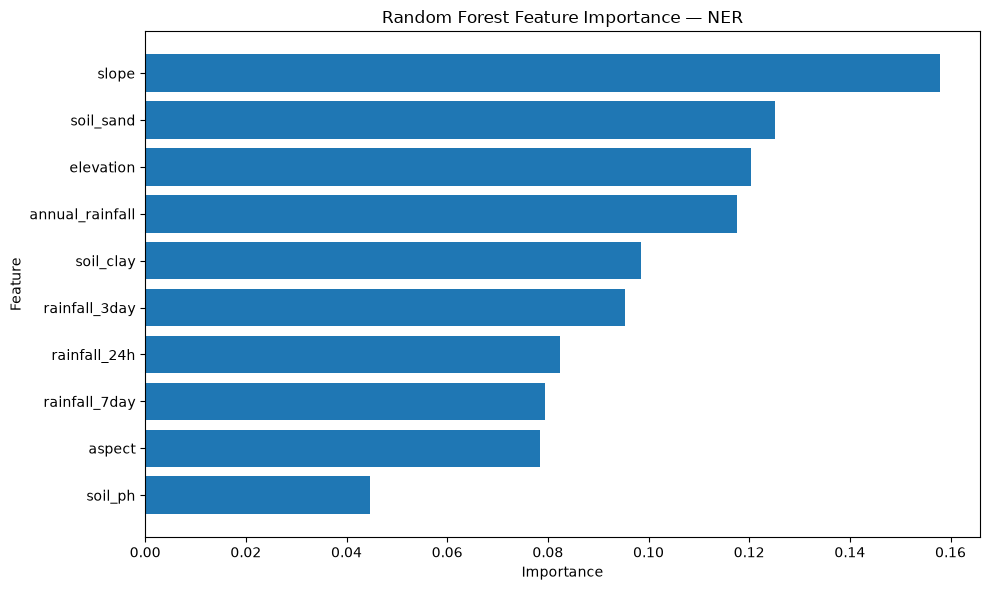


Model saved: ../models/landslide_model_dynamic.pkl


In [11]:
# ============================================================
# IMPROVED RANDOM FOREST — NER LANDSLIDE MODEL
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. LOAD DYNAMIC DATASET
# ------------------------------------------------------------

FILE = "../data/ner_dataset_dynamic.csv"

df = pd.read_csv(FILE)

print("Dataset loaded")
print("Rows:", len(df))

# ------------------------------------------------------------
# 2. FEATURES
# ------------------------------------------------------------

FEATURES = [
    "elevation",
    "slope",
    "aspect",
    "annual_rainfall",
    "soil_clay",
    "soil_sand",
    "soil_ph",
    "rainfall_24h",
    "rainfall_3day",
    "rainfall_7day"
]

TARGET = "landslide"

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("\nFeatures:")
for feature in FEATURES:
    print(" -", feature)

print("\nTarget:", TARGET)

# ------------------------------------------------------------
# 3. CHECK DATA
# ------------------------------------------------------------

print("\nMissing values:")
print(X.isna().sum())

print("\nClass distribution:")
print(y.value_counts())

# ------------------------------------------------------------
# 4. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# ------------------------------------------------------------
# 5. RANDOM FOREST
# ------------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest...")

model.fit(
    X_train,
    y_train
)

print("Training complete.")

# ------------------------------------------------------------
# 6. PREDICTION
# ------------------------------------------------------------

y_pred = model.predict(X_test)

# ------------------------------------------------------------
# 7. METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("\n========================================")
print("MODEL PERFORMANCE")
print("========================================")

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1 Score : {f1:.4f}"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

# ------------------------------------------------------------
# 8. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------------------
# 9. FEATURE IMPORTANCE
# ------------------------------------------------------------

importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print("\n========================================")
print("FEATURE IMPORTANCE")
print("========================================")

print(importance.to_string(index=False))

# ------------------------------------------------------------
# 10. PLOT FEATURE IMPORTANCE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(
    "Random Forest Feature Importance — NER"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 11. SAVE MODEL
# ------------------------------------------------------------

import joblib
import os

os.makedirs(
    "../models",
    exist_ok=True
)

MODEL_FILE = "../models/landslide_model_dynamic.pkl"

joblib.dump(
    model,
    MODEL_FILE
)

print(
    "\nModel saved:",
    MODEL_FILE
)

///////////////////////

In [ ]:
# ============================================
# STEP 1 — PREPARE DATA FOR MACHINE LEARNING
# ============================================


# Load final dataset
ner_dataset = pd.read_csv("../data/ner_dataset.csv")

# Features for the model
features = [
    "elevation",
    "slope",
    "aspect",
    "annual_rainfall",
    "soil_clay",
    "soil_sand",
    "soil_ph"
]

target = "landslide"

X = ner_dataset[features].copy()
y = ner_dataset[target].copy()

print("================================")
print("ML DATA PREPARATION")
print("================================")

print("Total rows:", len(ner_dataset))
print("Features:", features)
print("Number of features:", len(features))

print("\nMissing values:")
print(X.isna().sum())

print("\nTarget distribution:")
print(y.value_counts())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nDataset ready for train/test split.")

ML DATA PREPARATION
Total rows: 1288
Features: ['elevation', 'slope', 'aspect', 'annual_rainfall', 'soil_clay', 'soil_sand', 'soil_ph']
Number of features: 7

Missing values:
elevation          0
slope              0
aspect             0
annual_rainfall    0
soil_clay          0
soil_sand          0
soil_ph            0
dtype: int64

Target distribution:
landslide
1    707
0    581
Name: count, dtype: int64

X shape: (1288, 7)
y shape: (1288,)

Dataset ready for train/test split.


In [ ]:
# ============================================
# STEP 2 — TRAIN / TEST SPLIT
# ============================================


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("================================")
print("TRAIN / TEST SPLIT")
print("================================")

print("Total samples:", len(X))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain/test split completed successfully.")

NameError: name 'train_test_split' is not defined

In [ ]:
# ============================================
# STEP 3 — RANDOM FOREST MODEL
# ============================================

from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print()
print("================================")
print("RANDOM FOREST TRAINING COMPLETE")
print("================================")

print("Number of trees:", rf_model.n_estimators)
print("Training samples:", len(X_train))
print("Features used:", X_train.columns.tolist())

Training Random Forest...

RANDOM FOREST TRAINING COMPLETE
Number of trees: 300
Training samples: 1030
Features used: ['elevation', 'slope', 'aspect', 'annual_rainfall', 'soil_clay', 'soil_sand', 'soil_ph']


In [ ]:
# ============================================
# STEP 4 — EVALUATE RANDOM FOREST
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred = rf_model.predict(X_test)

# Probability for ROC-AUC
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("================================")
print("RANDOM FOREST EVALUATION")
print("================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Landslide", "Landslide"]
))

RANDOM FOREST EVALUATION
Accuracy : 0.7984
Precision: 0.8214
Recall   : 0.8099
F1 Score : 0.8156
ROC-AUC  : 0.8826

Confusion Matrix:
[[ 91  25]
 [ 27 115]]

Classification Report:
              precision    recall  f1-score   support

No Landslide       0.77      0.78      0.78       116
   Landslide       0.82      0.81      0.82       142

    accuracy                           0.80       258
   macro avg       0.80      0.80      0.80       258
weighted avg       0.80      0.80      0.80       258



In [ ]:
# ============================================
# STEP 5 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================

import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("================================")
print("FEATURE IMPORTANCE")
print("================================")

print(importance.to_string(index=False))

print("\nMost important feature:",
      importance.iloc[0]["Feature"])

FEATURE IMPORTANCE
        Feature  Importance
          slope    0.196836
      elevation    0.161553
annual_rainfall    0.160885
      soil_sand    0.151484
      soil_clay    0.134261
         aspect    0.125898
        soil_ph    0.069083

Most important feature: slope


In [ ]:
# ============================================
# STEP 10 — FIND BEST LANDSLIDE THRESHOLD
# ============================================

import numpy as np

# Use ORIGINAL Random Forest
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("================================")
print("THRESHOLD ANALYSIS")
print("================================")

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:

    y_threshold = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_test, y_threshold)
    prec = precision_score(y_test, y_threshold)
    rec = recall_score(y_test, y_threshold)
    f1 = f1_score(y_test, y_threshold)

    print(
        f"Threshold {threshold:.2f} | "
        f"Accuracy: {acc:.3f} | "
        f"Precision: {prec:.3f} | "
        f"Recall: {rec:.3f} | "
        f"F1: {f1:.3f}"
    )

THRESHOLD ANALYSIS
Threshold 0.30 | Accuracy: 0.713 | Precision: 0.663 | Recall: 0.972 | F1: 0.789
Threshold 0.35 | Accuracy: 0.760 | Precision: 0.711 | Recall: 0.951 | F1: 0.813
Threshold 0.40 | Accuracy: 0.791 | Precision: 0.759 | Recall: 0.908 | F1: 0.827
Threshold 0.45 | Accuracy: 0.798 | Precision: 0.796 | Recall: 0.852 | F1: 0.823
Threshold 0.50 | Accuracy: 0.798 | Precision: 0.821 | Recall: 0.810 | F1: 0.816
Threshold 0.55 | Accuracy: 0.787 | Precision: 0.848 | Recall: 0.746 | F1: 0.794
Threshold 0.60 | Accuracy: 0.767 | Precision: 0.866 | Recall: 0.683 | F1: 0.764


In [ ]:
# ============================================
# STEP 11 — SAVE FINAL MODEL
# ============================================

import joblib
import os

# Final model = ORIGINAL Random Forest
final_model = rf_model

# Warning threshold
final_threshold = 0.40

# Create models directory
os.makedirs("../models", exist_ok=True)

# Save model
joblib.dump(
    final_model,
    "../models/landslide_model.pkl"
)

# Save threshold
joblib.dump(
    final_threshold,
    "../models/threshold.pkl"
)

print("================================")
print("FINAL MODEL SAVED")
print("================================")

print("Model: Random Forest")
print("Trees:", final_model.n_estimators)
print("Features:", X_train.columns.tolist())
print("Threshold:", final_threshold)

print()
print("Files created:")
print("../models/landslide_model.pkl")
print("../models/threshold.pkl")

FINAL MODEL SAVED
Model: Random Forest
Trees: 300
Features: ['elevation', 'slope', 'aspect', 'annual_rainfall', 'soil_clay', 'soil_sand', 'soil_ph']
Threshold: 0.4

Files created:
../models/landslide_model.pkl
../models/threshold.pkl


In [ ]:
import json

with open("../data/india_states.geojson", "r", encoding="utf-8") as f:
    geo = json.load(f)

print(geo["features"][0]["properties"])

{'shapeName': 'Puducherry', 'shapeISO': 'IN-PY', 'shapeID': '1811400B81659894240990', 'shapeGroup': 'IND', 'shapeType': 'ADM1'}


In [ ]:
import json

with open("../data/india_states.geojson", "r", encoding="utf-8") as f:
    geo = json.load(f)

state_names = sorted(
    feature["properties"]["shapeName"]
    for feature in geo["features"]
)

print(state_names)

['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunāchal Pradesh', 'Assam', 'Bihār', 'Chandīgarh', 'Chhattīsgarh', 'Delhi', 'Dādra and Nagar Haveli and Damān and Diu', 'Goa', 'Gujarāt', 'Haryāna', 'Himāchal Pradesh', 'Jammu and Kashmīr', 'Jhārkhand', 'Karnātaka', 'Kerala', 'Ladākh', 'Lakshadweep', 'Madhya Pradesh', 'Mahārāshtra', 'Manipur', 'Meghālaya', 'Mizoram', 'Nāgāland', 'Odisha', 'Puducherry', 'Punjab', 'Rājasthān', 'Sikkim', 'Tamil Nādu', 'Telangāna', 'Tripura', 'Uttar Pradesh', 'Uttarākhand', 'West Bengal']
